# NBA Fantasy Basketball: Next-Season Performance Forecasting

**Author:** Joseph Nounagnon
**Tools:** Python, pandas, NumPy, scikit-learn, statsmodels, nba_api

## What this project is
An end to end data science project that forecasts an NBA player's next-season fantasy
average from their prior-season statistics, scored under a custom ESPN points league. The
central question: do advanced box score stats (efficiency, usage, defensive rate stats)
predict next-season production beyond what last season's raw average already tells us?

## How to read this notebook
The notebook runs top to bottom (Restart & Run All) and is organized into parts:

1. **Part 1**, building and hand-verifying the custom fantasy scoring function
2. **Part 2**, data collection and cleaning via nba_api
3. **Part 3**, filtering players to a meaningful sample, with the threshold validated empirically
4. **Part 4**, building the season over season training dataset
5. **Part 5**, feature engineering and modeling (baseline, age, advanced rate stats)

The **Project Summary & Conclusion** near the end states the headline finding. Two
appendices follow: a **Debugging Log** recording every bug and its fix, and a **Concepts
Log** listing the data science concepts applied throughout. Both are kept deliberately, the
process and the reasoning are part of the work, including the wrong turns.

## Headline result
The final model uses last season's average plus age (test R squared 0.766). Advanced rate
stats did not add predictive value beyond that, a negative result documented in full rather
than hidden. See the conclusion for why that is a legitimate and useful finding.

## Note on reproducibility
Player birthdates are fetched once from the API and cached to a CSV, so re-runs load from
disk instead of re-calling the API. A few cells in Part 3 make live API calls to reproduce
a data quality investigation and require a working connection.

---


# NBA Fantasy Basketball Forecasting Model

**Goal:** Predict a player's next-season average fantasy points using their current-season
statistics, scored under my ESPN league's custom scoring settings.

**Why this project:** Fantasy points in a points league are a deterministic formula of the
box score, so calculating *this* season's total is arithmetic, not modeling. The actual
predictive problem is forecasting *next* season, where aging, role changes, and injury
create genuine uncertainty. That forecast is what a draft cheat sheet needs.

---

---

### A note on this notebook's structure

This notebook is written in the order the work actually happened, including the wrong turns.
Two things in particular were discovered by mistake and then corrected:

1. The data was first filtered to the regular season using **hardcoded start/end dates**.
 That approach quietly swept in the **All-Star Game**, whose exhibition stats would have
 biased the averages of exactly the star players who matter most. Cross-checking the date
 filter against the API's own `season_type_nullable='Regular Season'` classification
 surfaced the discrepancy, and the pipeline was switched to the API parameter.

2. An earlier version appended its filtering fixes at the *bottom* of the notebook, after
 the cells that consumed the data, so it no longer reproduced top-to-bottom. This version
 filters at the point of each data pull.

The original discovery cells are preserved (Part 3) because the *process*, noticing two
methods disagreed, and chasing down why, is part of what the project demonstrates. The
full record of every bug is in the Debugging Log at the end.

## Setup

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nba_api.stats.endpoints import playergamelogs

# Part 1: Creating and Testing the Fantasy Calculator Function

In [2]:
# This is the function that calculates the fantasy points for a player

def calculate_fantasy_points(points, fgm, fga, ftm, fta, FG3M, rebounds, assists,
                             steals, blocks, TOV, ejections, flagrant_fouls):

    # Missed shots are not in the raw box score, so they are derived here:
    # missed = attempted - made
    fantasy_points = ((points * 1) + (fgm * 1) + ((fga - fgm) * -0.5)
                      + (ftm * 0.5) + ((fta - ftm) * -0.5) + (FG3M * 1.5)
                      + (rebounds * 1.5) + (assists * 2) + (steals * 4)
                      + (blocks * 4) + (TOV * -2) + (ejections * -3)
                      + (flagrant_fouls * -3))

    # Flags are initialized to False so they always have a value, even when the
    # conditions below don't trigger (see Bug 5 in the debugging log)
    double_doubles = False
    triple_doubles = False
    quadruple_doubles = False

    # Only PTS, REB, AST, STL, BLK count toward bonus tiers. Turnovers do not.
    qualifying_stats = [points, rebounds, assists, steals, blocks]
    categories_in_double_digits = sum(1 for stat in qualifying_stats if stat >= 10)

    if categories_in_double_digits >= 2:
        double_doubles = True
    if categories_in_double_digits >= 3:
        triple_doubles = True
    if categories_in_double_digits >= 4:
        quadruple_doubles = True

    # Bonuses stack: a triple-double earns both the DD and TD bonus
    if double_doubles:
        fantasy_points = fantasy_points + 2

    if triple_doubles:
        fantasy_points = fantasy_points + 3

    if quadruple_doubles:
        fantasy_points = fantasy_points + 100

    return fantasy_points

In [3]:
# Test case: Nikola Jokic, 4/27 vs MIN.
# Hand-calculated to 94.5 before this function was written, so the expected
# value is known independently of the code.

test_result = calculate_fantasy_points(
    points=27, fgm=9, fga=15, ftm=8, fta=10, FG3M=1,
    rebounds=12, assists=16, steals=0, blocks=2, TOV=3,
    ejections=0, flagrant_fouls=0
)

print(f"Function returned: {test_result}")
print(f"Hand calculation:  94.5")
print(f"Match: {test_result == 94.5}")

Function returned: 94.5
Hand calculation:  94.5
Match: True


# Part 1 Summary: Creating and Testing the Fantasy Points Calculator Function

## Overview
Before writing any code, the league's custom ESPN scoring rules were documented and
verified by hand-calculating two real player game logs. This ensured the formula was
fully understood before being translated into Python, catching any misunderstandings
early rather than after the code was written.

## Step 1: Documented the League's Custom Scoring Rules
- Pulled the exact scoring settings from the ESPN Fantasy app (screenshot verified)
- Confirmed the league is using **custom settings**, not ESPN's default formula
- Final scoring rules documented:

| Stat | Points |
|---|---|
| Points (PTS) | +1 |
| Field Goals Made (FGM) | +1 |
| Field Goals Missed (FGMI) | -0.5 |
| Free Throws Made (FTM) | +0.5 |
| Free Throws Missed (FTMI) | -0.5 |
| Three Pointers Made (3PM) | +1.5 |
| Rebounds (REB) | +1.5 |
| Assists (AST) | +2 |
| Steals (STL) | +4 |
| Blocks (BLK) | +4 |
| Turnovers (TOV) | -2 |
| Ejections | -3 |
| Flagrant Fouls | -3 |
| Double Double | +2 |
| Triple Double | +3 |
| Quadruple Double | +100 |

## Step 2: Hand-Calculated Two Real Player Game Logs
Before writing any code, the formula was verified manually on two real games:

**Game 1, Stephen Curry**
- Purpose: Verify the basic linear formula with no bonus tiers triggered
- Result: 36.5 fantasy points, matched hand calculation exactly

**Game 2, Nikola Jokic (4/27)**
- Purpose: Stress-test the bonus tier logic (double-double and triple-double)
- Stats: 27 PTS, 12 REB, 16 AST, 0 STL, 2 BLK, triggered both DD and TD bonuses
- Result: 94.5 fantasy points, matched hand calculation exactly
- Key learning: DD and TD bonuses stack (+2 and +3 applied together = +5 total)

## Step 3: Wrote the `calculate_fantasy_points` Python Function
- Function takes raw box score stats as inputs and returns a fantasy point total
- FGMI and FTMI are derived internally (FGA - FGM and FTA - FTM) since raw datasets
 don't include a "missed" column
- Bonus logic derives DD/TD/QD flags internally from raw stats rather than accepting
 them as parameters, ensures the function works correctly on any dataset
- Qualifying categories for bonus tiers: PTS, REB, AST, STL, BLK (turnovers excluded
 per ESPN convention)
- Bonus tiers stack, a triple-double awards both the +2 DD bonus and the +3 TD bonus

## Step 4: Verified the Function Against Hand-Calculated Results
- Tested on hardcoded Jokic stats, function returned 94.5, matching hand calculation
- Confirmed the function handles all edge cases: no bonuses, double-double,
 triple-double, and quadruple-double branches all implemented correctly

Five bugs were encountered during development, see the Debugging Log at the end of
this notebook for the full record of each bug, how it was caught, and how it was fixed.

# Part 2: Data Collection & Pipeline Helpers

## Overview
Data comes from the `nba_api` library's `PlayerGameLogs` endpoint, which returns one row
per player per game. Two seasons are needed: 2022-23 supplies the features, 2023-24
supplies the target the model is trying to predict.

Because the same sequence of operations runs on both seasons, each step is written once
as a reusable function. This avoids copy-paste divergence, an early version of this
notebook had slightly different filter logic for each season, which is exactly how silent
inconsistencies get introduced.

## Column mapping
The API's column names don't all match the names used in the scoring settings:

| Scoring setting | API column |
|---|---|
| Turnovers | `TOV` (not `TO`) |
| Three Pointers Made | `FG3M` (not `3PM`) |
| Rebounds | `REB` (total; `OREB`/`DREB` are separate and not used) |

Ejections and flagrant fouls are not tracked in this dataset and are passed as 0.

The API also provides `DD2`, `TD3`, and `NBA_FANTASY_PTS` columns. These are deliberately
**not** used, `NBA_FANTASY_PTS` uses a different scoring system than my league, and
deriving the bonus flags from raw stats demonstrates understanding of the data rather
than dependence on a precomputed column.

In [4]:
# Applies the fantasy points formula to every row of a game-log DataFrame

def add_fantasy_points(df):
    df['FANTASY_POINTS'] = df.apply(lambda row: calculate_fantasy_points(
        row['PTS'], row['FGM'], row['FGA'], row['FTM'], row['FTA'],
        row['FG3M'], row['REB'], row['AST'], row['STL'], row['BLK'],
        row['TOV'], 0, 0
    ), axis=1)
    return df

In [5]:
# Collapses game logs into one row per player.
#
# Grouped on PLAYER_ID rather than PLAYER_NAME: names are not stable across seasons
# (suffixes like "Jimmy Butler III", accented characters, spelling corrections), and a
# single mismatch would silently drop that player from the season-over-season merge
# with no error. IDs are stable.

def summarize_season(df):
    return df.groupby('PLAYER_ID').agg(
        player_name=('PLAYER_NAME', 'first'),
        games_played=('GAME_ID', 'count'),
        avg_minutes=('MIN', 'mean'),
        avg_fantasy_points=('FANTASY_POINTS', 'mean')
    ).reset_index()

In [6]:
# Keeps only players with a real, sustained role.
#
# 20+ games ensures the per-game average is based on enough of a sample to stabilize.
# 15+ MPG filters out garbage-time and deep-bench players whose rate stats are erratic.
# Both thresholds are validated empirically further below rather than assumed.

def apply_thresholds(summary, min_games=20, min_minutes=15):
    return summary[
        (summary['games_played'] >= min_games) &
        (summary['avg_minutes'] >= min_minutes)
    ].copy()

In [7]:
# Pulls one season of regular-season game logs and computes fantasy points.
#
# Uses the API's own season_type_nullable='Regular Season' classification rather than
# hardcoded date boundaries. This choice was NOT the first approach, see Part 3 for the
# investigation that led here. In short, it is both more correct and more maintainable:
#
#   - Excludes the All-Star Game, which a date filter sweeps in. All-Star stats are
#     inflated exhibition numbers that would bias the averages of the league's best
#     players, who are exactly the ones the model cares most about.
#   - Excludes preseason, play-in, and playoffs by the league's own definition.
#   - KEEPS legitimate edge cases: In-Season Tournament games that count toward stats,
#     and the rare 83rd/84th game a traded player picks up from a team's larger
#     remaining schedule.
#   - Needs no per-season date lookup: scales to any season by changing one string.

def load_season(season):
    df = playergamelogs.PlayerGameLogs(
        season_nullable=season,
        season_type_nullable='Regular Season'
    ).get_data_frames()[0]

    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
    df = add_fantasy_points(df)

    print(f"{season}: {len(df)} regular season game logs")
    print(f"  date range: {df['GAME_DATE'].min().date()} to {df['GAME_DATE'].max().date()}")
    print(f"  max games by one player: {df.groupby('PLAYER_ID').size().max()}")

    return df

### On the regular-season filter

The pipeline above uses the API's `season_type_nullable='Regular Season'` parameter to
restrict the pull to regular-season games. This replaced an earlier hardcoded-date
approach.

The full reasoning, including how the two methods were compared and what the mismatch
turned out to be, is documented in **Part 3**, where the discovery actually happened while
validating the player-count filter. It is kept there rather than hidden here because it is
one of the more instructive moments in the project.

In [8]:
# 2022-23 season, supplies the model's features
df_2223 = load_season('2022-23')

2022-23: 25894 regular season game logs
  date range: 2022-10-18 to 2023-04-09
  max games by one player: 83


In [9]:
# 2023-24 season, supplies the model's target variable
df_2324 = load_season('2023-24')

2023-24: 26401 regular season game logs
  date range: 2023-10-24 to 2024-04-14
  max games by one player: 84


In [10]:
# Sanity check on the fantasy points distribution for both seasons.
#
# Negative minimums are expected and correct: a player who goes 0-for-6 with a couple
# of turnovers in garbage time genuinely scores negative under this league's settings.

print("2022-23")
print(df_2223['FANTASY_POINTS'].describe())
print()
print("2023-24")
print(df_2324['FANTASY_POINTS'].describe())

2022-23
count    25894.000000
mean        28.239245
std         20.412881
min         -8.000000
25%         12.000000
50%         25.250000
75%         41.000000
max        144.500000
Name: FANTASY_POINTS, dtype: float64

2023-24
count    26401.000000
mean        28.303492
std         20.971580
min        -12.500000
25%         11.500000
50%         25.000000
75%         41.500000
max        141.500000
Name: FANTASY_POINTS, dtype: float64


# Part 2 Summary: Data Collection & Fantasy Points Calculation

## Step 1: Pulled Two Seasons of Game Logs
- Used `nba_api`'s `PlayerGameLogs` endpoint for 2022-23 and 2023-24
- Each row is one player's stat line for one game

## Step 2: Identified the Relevant Columns
- Ran `df.columns.tolist()` to see all 70 available columns
- Confirmed the column names needed for the fantasy points formula
- Noted that turnovers is `TOV` (not `TO`) and three pointers made is `FG3M` (not `3PM`)
- Ejections and flagrant fouls are not tracked in this dataset, defaulted to 0

## Step 3: Filtered to Regular Season Games Only
- Used the API's `season_type_nullable='Regular Season'` classification, which excludes
 preseason, play-in, playoffs, AND the All-Star Game
- This replaced an earlier hardcoded-date approach that incorrectly included the All-Star
 Game (see Part 3 for the investigation)
- Converted `GAME_DATE` to datetime for downstream date-based work

## Step 4: Applied the Fantasy Points Formula
- Used `df.apply()` with a lambda to pass each row's stats into `calculate_fantasy_points()`
- Verified against a single known row (Jayson Tatum, 2024-06-17, 81.0) before applying to
 the full dataset, spot-checking one row against a hand calculation before running on
 thousands is a habit that catches column-mapping errors early

## Step 5: Ran a Sanity Check
- Checked the distribution of fantasy points for both seasons
- Means sit near 28 points per game for both, which is consistent
- Negative minimums confirmed as valid, not a bug

# Part 3: Filtering Players by Minimum Games and Minutes Threshold

## Overview
Not every row in the dataset represents a meaningful sample. Players who appeared in
only a handful of games, or who averaged very few minutes, produce noisy and
unreliable fantasy point averages. Before building any model, the dataset needs to be
filtered down to player-seasons that represent a real, sustained role on their team.

## The Threshold Decision
The following minimum thresholds were chosen for v1 of the model:
- **Games Played: 20+**, ensures enough games for per-game averages to stabilize
- **Minutes Per Game: 15+**, filters out garbage-time and deep bench players whose
 stats are erratic and not representative of a real role

These follow standard NBA analytics convention. Rather than accepting them on authority,
they are validated against the actual data below.

## Scope Decision: Rookies and Insufficient Prior-Season Data
Players with no previous-season NBA data (rookies, or players who missed nearly an
entire prior season) are **excluded from v1** of the model. This is a deliberate
scope decision documented here so it can be spoken to in an interview:
- The model requires prior-season stats as features to predict next-season output
- Without prior-season data, there are no features to feed the model
- Rookie projection would require an entirely different feature set (college/international
 statistics, draft position, physical measurements) and is a **separate future workstream**,
 explicitly out of scope for v1

In [11]:
# Distribution of all players before any filtering is applied

summary_2223_all = summarize_season(df_2223)
summary_2324_all = summarize_season(df_2324)

print("2022-23, all players")
print(summary_2223_all[['games_played', 'avg_minutes', 'avg_fantasy_points']].describe())
print()
print("2023-24, all players")
print(summary_2324_all[['games_played', 'avg_minutes', 'avg_fantasy_points']].describe())

2022-23, all players
       games_played  avg_minutes  avg_fantasy_points
count    539.000000   539.000000          539.000000
mean      48.040816    19.796616           23.908201
std       24.650686     9.540921           15.417603
min        1.000000     1.033333           -2.500000
25%       30.500000    12.453345           12.275245
50%       54.000000    19.184691           20.250000
75%       68.000000    28.346412           32.654977
max       83.000000    40.783333           75.318182

2023-24, all players
       games_played  avg_minutes  avg_fantasy_points
count    572.000000   572.000000          572.000000
mean      46.155594    18.648635           22.810618
std       25.536868     9.914316           15.954170
min        1.000000     0.350000           -0.500000
25%       22.000000    10.779994           10.580556
50%       51.000000    17.349140           19.202300
75%       69.000000    27.043097           32.393569
max       84.000000    37.829979           83.392857


### Validating the threshold empirically

The justification for a minutes threshold is that low-minute players produce unstable
averages. That claim is testable: if it's true, the spread of fantasy point averages
should shrink as total minutes played increases, and should flatten out somewhere.

The plot below bins players by total minutes and shows the standard deviation of their
per-game fantasy point averages within each bin. If variance stabilizes near the chosen
cutoff, the threshold is defensible. If it stabilizes somewhere else, the threshold
should move.

In [12]:
# Total minutes played is a better stability proxy than either games or MPG alone:
# it captures both how often a player appeared and how large their role was.

stability = summary_2223_all.copy()
stability['total_minutes'] = stability['games_played'] * stability['avg_minutes']

# Bin players by total minutes and measure how much fantasy point averages vary
# within each bin
bins = [0, 100, 250, 500, 750, 1000, 1500, 2000, 3000]
stability['minutes_bin'] = pd.cut(stability['total_minutes'], bins=bins)

variance_by_bin = stability.groupby('minutes_bin', observed=True).agg(
    player_count=('player_name', 'count'),
    std_fantasy_points=('avg_fantasy_points', 'std'),
    mean_fantasy_points=('avg_fantasy_points', 'mean')
).reset_index()

print(variance_by_bin)

    minutes_bin  player_count  std_fantasy_points  mean_fantasy_points
0      (0, 100]            71            8.835859             8.834788
1    (100, 250]            52            7.803007            12.308969
2    (250, 500]            49            6.247072            13.054968
3    (500, 750]            43            5.439018            15.122017
4   (750, 1000]            61            8.337562            19.114474
5  (1000, 1500]            73            7.579546            24.222030
6  (1500, 2000]            85           12.314821            34.214259
7  (2000, 3000]           105           12.125418            42.731815


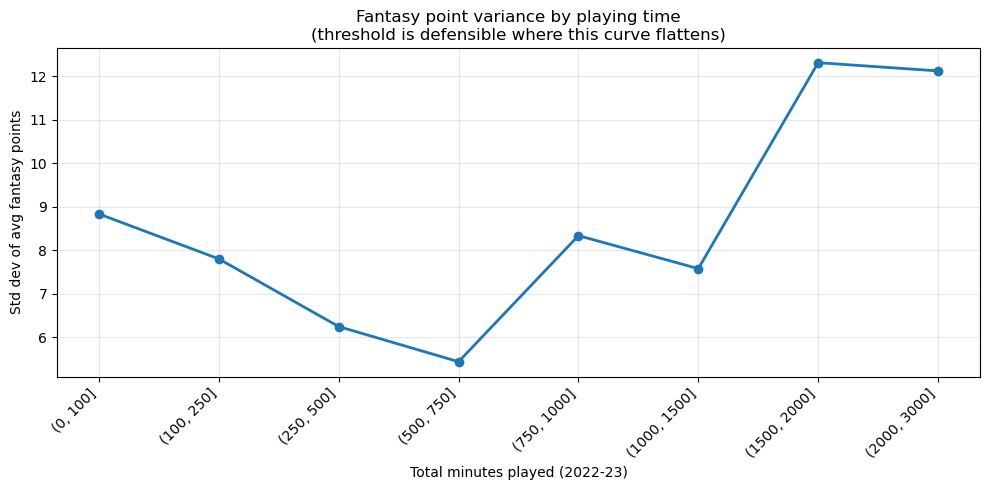

In [13]:
# Visualizing the results.

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(variance_by_bin)), variance_by_bin['std_fantasy_points'],
        marker='o', linewidth=2)
ax.set_xticks(range(len(variance_by_bin)))
ax.set_xticklabels([str(b) for b in variance_by_bin['minutes_bin']],
                   rotation=45, ha='right')
ax.set_xlabel('Total minutes played (2022-23)')
ax.set_ylabel('Std dev of avg fantasy points')
ax.set_title('Fantasy point variance by playing time\n'
             '(threshold is defensible where this curve flattens)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Visualization Synopsis:

The plot above does not show what I was expecting, which was a downward slope. Instead, it’s more
like a Nike logo or a checkmark.

After thinking about it, I think the chart is measuring two separate things on the right and the
left, which explains why the chart looks the way it does.

The left side is unreliable because players with low minutes are pulling an average from a handful
of games played. A player with 80 total minutes might have an average built off four or five games,
which tells us very little about how good they actually are.

Two players may both be in the starting lineup and average similar large minutes,
but are tasked to do different things. For example, Anthony Edwards and Rudy Gobert may play a similar
amount, but Anthony Edwards has a higher usage rate and is asked to do more compared to Gobert, whose
primary role is to grab rebounds, play defense, and protect the rim.


### Conclusion:

The problem isn't that standard deviation is a bad metric, it's that measuring the spread *across*
players answers a different question than the one I was asking. I wanted to know how precisely I
know any single player's average. Spread between players and precision within one player's estimate
are two different quantities, and this chart was measuring the wrong one.

Standard error should work better. It measures each player's own game-to-game variation against
their own sample size, so differences between players drop out entirely and only the reliability
of the estimate is left.

In [14]:
# Standard Error diagnostic.


player_precision = df_2223.groupby('PLAYER_ID').agg(
    player_name=('PLAYER_NAME', 'first'),
    games_played=('GAME_ID', 'count'),
    avg_minutes=('MIN', 'mean'),
    avg_fantasy_points=('FANTASY_POINTS', 'mean'),
    game_to_game_std=('FANTASY_POINTS', 'std')
).reset_index()

# Players with a single game have no game-to-game spread to measure
player_precision = player_precision[player_precision['games_played'] >= 2].copy()

player_precision['total_minutes'] = (
    player_precision['games_played'] * player_precision['avg_minutes']
)

player_precision['standard_error'] = (
    player_precision['game_to_game_std'] / np.sqrt(player_precision['games_played'])
)

bins = [0, 100, 250, 500, 750, 1000, 1500, 2000, 3000]
player_precision['minutes_bin'] = pd.cut(player_precision['total_minutes'], bins=bins)

precision_by_bin = player_precision.groupby('minutes_bin', observed=True).agg(
    player_count=('player_name', 'count'),
    median_games=('games_played', 'median'),
    mean_standard_error=('standard_error', 'mean'),
    mean_fantasy_points=('avg_fantasy_points', 'mean')
).reset_index()

print(precision_by_bin.to_string(index=False))

 minutes_bin  player_count  median_games  mean_standard_error  mean_fantasy_points
    (0, 100]            62           6.0             3.861538             7.714032
  (100, 250]            52          18.0             2.932835            12.308969
  (250, 500]            49          35.0             2.057554            13.054968
  (500, 750]            43          43.0             1.867356            15.122017
 (750, 1000]            61          54.0             1.824988            19.114474
(1000, 1500]            73          62.0             1.818812            24.222030
(1500, 2000]            85          67.0             1.809211            34.214259
(2000, 3000]           105          74.0             1.849632            42.731815


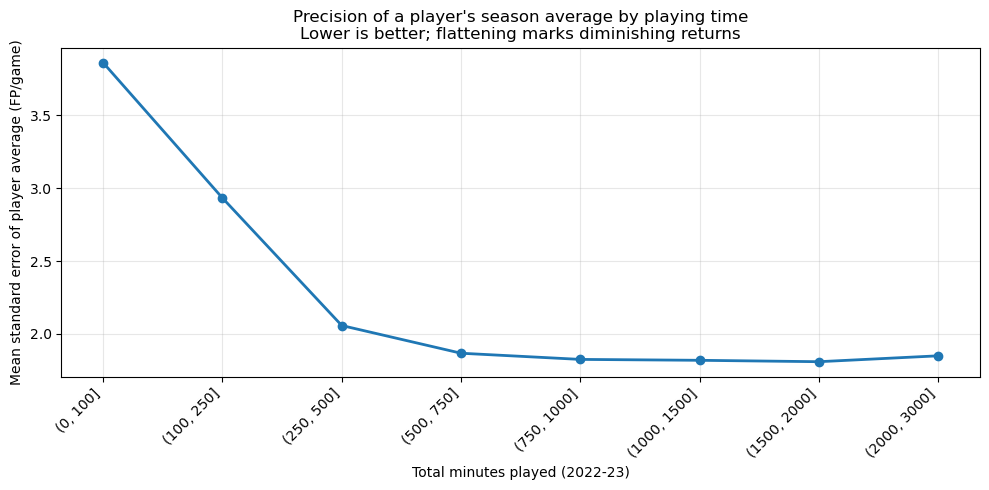

In [15]:
# Visualizing where the results.

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(precision_by_bin)), precision_by_bin['mean_standard_error'],
        marker='o', linewidth=2)
ax.set_xticks(range(len(precision_by_bin)))
ax.set_xticklabels([str(b) for b in precision_by_bin['minutes_bin']],
                   rotation=45, ha='right')
ax.set_xlabel('Total minutes played (2022-23)')
ax.set_ylabel('Mean standard error of player average (FP/game)')
ax.set_title('Precision of a player\'s season average by playing time\n'
             'Lower is better; flattening marks diminishing returns')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Standard Error Plot Synopsis:


**The results:** Precision improves steeply up to about 500 total minutes (SE 3.85 → 2.06),
then flattens, everything past 750 minutes sits near 1.82. Additional games stop buying
meaningful precision after that point.

The 20 GP × 15 MPG threshold implies a ~300 minute floor, landing at an SE near 2.0. That
is just below the elbow rather than past it. Tightening to 500 minutes would improve
precision by roughly 0.2 FP/game while shrinking an already small training set, so the
threshold stays where it is.

**The uptick at 2000+ minutes:** Expected, not a red flag. Standard error is measured in
fantasy points, and high-usage stars swing harder in absolute terms (a 40-point night
followed by a 65-point night) than bench players ever do. That volatility slightly offsets
their larger sample.

**Conclusion:** Threshold retained at 20 GP / 15 MPG, now a data-supported decision rather
than an inherited convention.

In [16]:
# Applying the threshold to both seasons

qualified_2223 = apply_thresholds(summary_2223_all)
qualified_2324 = apply_thresholds(summary_2324_all)

print(f"2022-23: {len(summary_2223_all)} players -> {len(qualified_2223)} qualified")
print(f"2023-24: {len(summary_2324_all)} players -> {len(qualified_2324)} qualified")

2022-23: 539 players -> 322 qualified
2023-24: 572 players -> 315 qualified


In [17]:
# Double Checking the maximum games played in each season to ensure that the filtering is correct and that no player has more than 82 games (the maximum in a regular NBA season).
print("Max games in a season (should be <= 82 if playoffs are filtered):")
print(f"  2022-23: {summary_2223_all['games_played'].max()}")
print(f"  2023-24: {summary_2324_all['games_played'].max()}")

Max games in a season (should be <= 82 if playoffs are filtered):
  2022-23: 83
  2023-24: 84


**Some players show more than 82 games.** At first this looks impossible, since each team
plays an 82-game regular season. Before assuming a data bug, the individual players need to
be identified and each overage explained. The next cell pulls them up.

In [18]:
# Who has more than 82 games in 2022-23, when the max possible is 82?
suspects_2223 = summary_2223_all[summary_2223_all['games_played'] > 82]
print(suspects_2223[['player_name', 'games_played', 'avg_minutes']].to_string(index=False))

# And 2023-24, where only IST finalists should exceed 82
suspects_2324 = summary_2324_all[summary_2324_all['games_played'] > 82]
print(suspects_2324[['player_name', 'games_played', 'avg_minutes']].to_string(index=False))

  player_name  games_played  avg_minutes
Mikal Bridges            83    35.700924
player_name  games_played  avg_minutes
Buddy Hield            84    25.712956


### Data Quality Note: Players Exceeding 82 Games

A small number of players show more than 82 games played in a single season. Each was
investigated individually, and all are legitimate regular-season games, kept in the
dataset. There are **two distinct causes**, which is why a single explanation didn't fit
all of them:

**Cause 1, mid-season trades.** A player traded to a team that has played *fewer* games
than his previous team inherits that team's larger remaining schedule. Playing every game
for both teams can push his personal total past 82. This requires perfect attendance and
the right trade timing, so it is rare, but the games are real.
- **Mikal Bridges (2022-23): 83 games.** Traded from Phoenix (56 games played) to Brooklyn
 in the Kevin Durant deal; played all 27 of Brooklyn's remaining games. Note this happened
 in 2022-23, *before* the In-Season Tournament existed, proof that trades, not the
 tournament, are this cause.
- **Buddy Hield (2023-24): 84 games.** Traded from Indiana to Philadelphia when Indiana had
 played more games than Philadelphia, picking up the surplus.

**Cause 2, the In-Season Tournament final (2023-24 only).** The IST debuted in 2023-24.
Its knockout games counted as regular-season games *except* the championship game, which
counts toward individual stats but not team standings. Players who reached the final
therefore pick up an extra counted game.
- **Austin Reaves, Obi Topin and other Lakers** (the IST champions) and **Pacers** players who reached
 the final show an extra game from that matchup.

**Why this matters, and why it's NOT the All-Star Game.** These overages are real
production and are kept. This is a *different* issue from the All-Star Game contamination
found later in this section: the All-Star Game is an exhibition whose stats are excluded,
while these trade/IST games are genuine competitive games whose stats belong in the data.

In [19]:
# How sensitive is the player pool to where the threshold is drawn?
#
# If a small change in the cutoff causes a large change in the sample size, the
# threshold is doing more work than it should be and deserves more scrutiny.

for games in [10, 15, 20, 25, 30]:
    for minutes in [10, 15, 20]:
        n = len(apply_thresholds(summary_2223_all, games, minutes))
        print(f"  {games:>2} GP, {minutes:>2} MPG -> {n:>3} players")

  10 GP, 10 MPG -> 414 players
  10 GP, 15 MPG -> 325 players
  10 GP, 20 MPG -> 239 players
  15 GP, 10 MPG -> 408 players
  15 GP, 15 MPG -> 324 players
  15 GP, 20 MPG -> 238 players
  20 GP, 10 MPG -> 398 players
  20 GP, 15 MPG -> 322 players
  20 GP, 20 MPG -> 238 players
  25 GP, 10 MPG -> 394 players
  25 GP, 15 MPG -> 320 players
  25 GP, 20 MPG -> 237 players
  30 GP, 10 MPG -> 382 players
  30 GP, 15 MPG -> 314 players
  30 GP, 20 MPG -> 234 players


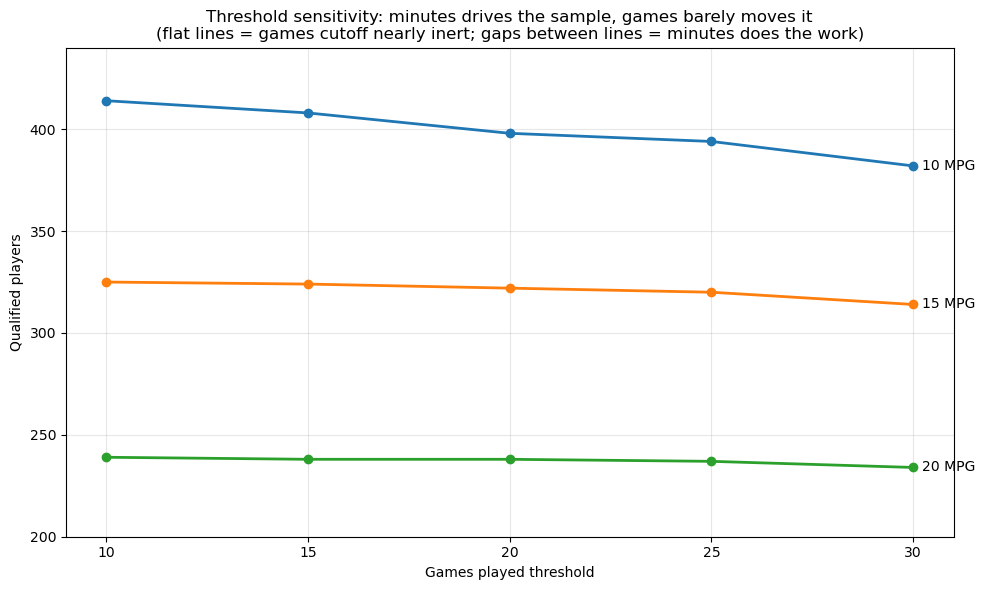

In [20]:
# Visualizing the threshold sensitivity grid.
#
# Three lines, one per minutes cutoff, plotted against the games-played threshold.
# Vertical spacing between lines = how much the MINUTES cutoff moves the sample.
# Slope of each line = how much the GAMES cutoff moves it.
#
# Rebuilt programmatically so the plot always matches the underlying data rather than
# hardcoded numbers that could silently go stale.

games_thresholds = [10, 15, 20, 25, 30]

results = {}
for minutes in [10, 15, 20]:
    results[minutes] = [
        len(apply_thresholds(summary_2223_all, g, minutes)) for g in games_thresholds
    ]

fig, ax = plt.subplots(figsize=(10, 6))
for minutes, counts in results.items():
    ax.plot(games_thresholds, counts, marker='o', linewidth=2)
    ax.annotate(f'{minutes} MPG', xy=(games_thresholds[-1], counts[-1]),
                xytext=(6, 0), textcoords='offset points', va='center', fontsize=10)

ax.set_xlabel('Games played threshold')
ax.set_ylabel('Qualified players')
ax.set_title('Threshold sensitivity: minutes drives the sample, games barely moves it\n'
             '(flat lines = games cutoff nearly inert; gaps between lines = minutes does the work)')
ax.set_xticks(games_thresholds)
ax.grid(alpha=0.3)
ax.set_ylim(200, 440)
plt.tight_layout()
plt.show()

### **Threshold Sensitivity Interpretation:** 

**The games threshold is nearly inert.** Holding minutes at 15 and swinging the games
cutoff from 10 to 30 moves the pool from 325 to 314 which is about a 3% change across a 3x swing
in the threshold. Each line in the plot is almost flat, confirming that where the games
cutoff is drawn barely affects who qualifies.

**The minutes threshold does the real work.** Holding games at 20 and swinging minutes
from 10 to 20 moves the pool from 398 to 238, which is about a 40% change. The wide vertical gaps
between the three lines are where all the movement lives.

**What this means for the filter.** The minutes threshold is effectively the entire filter;
the games threshold is almost redundant, because nearly every player logging 15+ minutes a
night also clears 20 games. This means 20 games is just a conventional floor, but the sensitivity
analysis showed the minutes cutoff was doing the actual filtering.

**No cliffs.** Every step in every line is gradual, there's no point where nudging a
threshold by one increment drops a large chunk of players. That means the dataset isn't
balanced on a knife's edge where an arbitrary choice swings the result. The 20 GP / 15 MPG
threshold is retained.

### Discovery: the hardcoded date filter was including the All-Star Game

Up to this point in the original work, the regular-season filter used **hardcoded start and
end dates**. Before committing to that permanently, it was worth checking against the API's
own `season_type_nullable='Regular Season'` classification, if they matched, the dates were
redundant; if they didn't, the difference would be informative.

The cells below are the actual investigation, kept intact. They compare the two methods,
isolate the games that differ, and identify what those games are. The conclusion is what
justifies the `load_season` implementation used in Part 2.

In [21]:
# Compare the API's Regular Season classification against the date-filtered approach.
# NOTE: df_2223 is now already API-filtered (Part 2 was updated after this discovery).
# To reproduce the ORIGINAL comparison, this cell rebuilds a date-filtered version.

date_filtered_2223 = playergamelogs.PlayerGameLogs(
    season_nullable='2022-23'
).get_data_frames()[0]
date_filtered_2223['GAME_DATE'] = pd.to_datetime(date_filtered_2223['GAME_DATE'])
date_filtered_2223 = date_filtered_2223[
    (date_filtered_2223['GAME_DATE'] >= '2022-10-18') &
    (date_filtered_2223['GAME_DATE'] <= '2023-04-09')
].copy()

api_filtered_2223 = playergamelogs.PlayerGameLogs(
    season_nullable='2022-23',
    season_type_nullable='Regular Season'
).get_data_frames()[0]

print(f"Date-filtered rows: {len(date_filtered_2223)}")
print(f"API Regular Season rows: {len(api_filtered_2223)}")
print(f"Match: {len(date_filtered_2223) == len(api_filtered_2223)}")

Date-filtered rows: 25918
API Regular Season rows: 25894
Match: False


In [22]:
# The counts don't match. Isolate exactly which games the date filter kept that the
# API's Regular Season set excluded.

date_ids = set(date_filtered_2223['GAME_ID'])
api_ids = set(api_filtered_2223['GAME_ID'])
extra_ids = date_ids - api_ids

print(f"Games in date-filter but not in API Regular Season: {len(extra_ids)}")

extra_rows = date_filtered_2223[date_filtered_2223['GAME_ID'].isin(extra_ids)]
print(extra_rows[['GAME_DATE', 'MATCHUP', 'PLAYER_NAME']].sort_values('GAME_DATE').head(30))

Games in date-filter but not in API Regular Season: 1
      GAME_DATE      MATCHUP              PLAYER_NAME
9097 2023-02-19    GNS @ LBN             Jayson Tatum
9118 2023-02-19    GNS @ LBN              Bam Adebayo
9117 2023-02-19    GNS @ LBN             Jrue Holiday
9116 2023-02-19  LBN vs. GNS        Jaren Jackson Jr.
9115 2023-02-19    GNS @ LBN         Domantas Sabonis
9114 2023-02-19  LBN vs. GNS              Luka Dončić
9113 2023-02-19    GNS @ LBN                Ja Morant
9112 2023-02-19  LBN vs. GNS              Paul George
9111 2023-02-19  LBN vs. GNS          Anthony Edwards
9110 2023-02-19  LBN vs. GNS            Julius Randle
9109 2023-02-19  LBN vs. GNS             LeBron James
9108 2023-02-19    GNS @ LBN  Shai Gilgeous-Alexander
9107 2023-02-19    GNS @ LBN            DeMar DeRozan
9106 2023-02-19  LBN vs. GNS             Nikola Jokić
9105 2023-02-19    GNS @ LBN          Lauri Markkanen
9104 2023-02-19    GNS @ LBN            Pascal Siakam
9103 2023-02-19  LBN vs. GNS

### It was the All-Star Game

The mismatch is a single game (one `GAME_ID`), dated mid-February, with a "GNS vs. LBN"
matchup (Team Giannis vs. Team LeBron) and a roster made up entirely of the league's stars.
That is the **All-Star Game**, an exhibition, not a regular-season game.

This is exactly the kind of contaminant that matters: All-Star Game box scores are inflated
(no defense, blowout pace) and they attach to the *best* players in the league, the ones
whose averages the model most needs to get right. A date filter has no way to exclude it
without special-casing a date that changes every year.

**Decision:** switch the pipeline to `season_type_nullable='Regular Season'`. It excludes
the All-Star Game automatically, keeps the legitimate trade/IST overages, and removes the
need to look up start/end dates for every new season. Part 2's `load_season` was rewritten
to use this parameter, this discovery is *why* it looks the way it does.

# Part 3 Summary: Threshold Filtering

- Computed per-player season summaries grouped on `PLAYER_ID`
- Validated the minutes threshold empirically by measuring how fantasy point variance
 changes with total playing time, rather than accepting a convention on authority
- Ran a sensitivity check across a grid of thresholds to confirm the player pool doesn't
 swing wildly on small changes to the cutoff
- Applied a 20 games / 15 MPG filter to both seasons
- Discovered, by cross-checking the hardcoded date filter against the API's
 `season_type_nullable` parameter, that the date approach was including the All-Star Game;
 switched the pipeline to the API classification as a result
- Confirmed the API filter keeps legitimate >82-game cases (trades, IST final) while
 dropping the All-Star Game

# Part 4: Building the Season-over-Season Dataset

## Overview
The core of this forecasting model is predicting a player's fantasy point output
next season using their stats from the current season. This requires pairing two
seasons of data for each player:
- **Feature season (X): 2022-23**, the stats fed into the model
- **Target season (Y): 2023-24**, the fantasy points the model is trying to predict

The merge is an inner join, so it keeps only players who cleared the threshold in *both*
seasons. Players who retired, missed a full season, or were rookies in 2023-24 drop out
here automatically, which matches the v1 scope decision made in Part 3.

## Column naming
Both seasons contribute `games_played` and `avg_minutes`, so the merge suffixes them by
season. These are kept as separate columns rather than averaged: a player who played 82
games one year and 40 the next tells a very different story from one who played 61 both
years, and averaging would collapse those into an identical number. The *gap* between the
two is itself signal about injury and role loss.

In [23]:
# Inner join on PLAYER_ID

merged = qualified_2223.merge(
    qualified_2324[['PLAYER_ID', 'games_played', 'avg_minutes', 'avg_fantasy_points']],
    on='PLAYER_ID',
    suffixes=('_2223', '_2324')
)

print(f"2022-23 qualified: {len(qualified_2223)}")
print(f"2023-24 qualified: {len(qualified_2324)}")
print(f"Merged (in both):  {len(merged)}")
merged.head(15)

2022-23 qualified: 322
2023-24 qualified: 315
Merged (in both):  243


,PLAYER_ID,player_name,games_played_2223,avg_minutes_2223,avg_fantasy_points_2223,games_played_2324,avg_minutes_2324,avg_fantasy_points_2324
0,2544,LeBron James,55,35.526182,65.681818,71,35.263146,64.528169
1,101108,Chris Paul,59,32.010763,47.601695,58,26.394655,34.965517
2,200768,Kyle Lowry,55,31.231364,34.327273,60,28.162778,27.808333
3,200782,P.J. Tucker,75,25.600733,14.373333,31,15.687527,10.016129
4,201142,Kevin Durant,47,35.569291,63.478723,75,37.208489,60.326667
5,201143,Al Horford,63,30.498016,35.039683,65,26.766103,32.492308
6,201144,Mike Conley,67,30.269478,36.873134,76,28.861294,36.230263
7,201145,Jeff Green,56,19.484226,17.651786,78,16.760748,15.467949
8,201566,Russell Westbrook,73,29.120913,44.061644,68,22.482598,32.536765
9,201567,Kevin Love,62,19.991586,24.870968,55,16.804788,26.627273


In [24]:
# Who dropped out of the merge, and why?
#
# Worth looking at directly rather than accepting the row count. If a recognizable
# starter is missing, that points to a data problem (a name/ID mismatch, a season
# split across teams) rather than a genuine absence.

dropped = qualified_2223[~qualified_2223['PLAYER_ID'].isin(merged['PLAYER_ID'])]
with pd.option_context('display.max_rows', None):
    print(dropped[['player_name', 'games_played', 'avg_minutes', 'avg_fantasy_points']]
          .sort_values('avg_fantasy_points', ascending=False)
          .to_string(index=False))


           player_name  games_played  avg_minutes  avg_fantasy_points
             Ja Morant            61    31.940137           58.983607
      Kevin Porter Jr.            59    34.303107           46.593220
          Steven Adams            42    26.983135           37.357143
         Mason Plumlee            79    25.986646           36.392405
           Ben Simmons            42    26.309921           33.452381
   Robert Williams III            35    23.530000           32.885714
          Monte Morris            62    27.356237           31.717742
             KJ Martin            82    27.953150           30.146341
             John Wall            34    22.197941           28.985294
         Mark Williams            43    19.255233           28.976744
        Victor Oladipo            42    26.324762           28.523810
        Brandon Clarke            56    19.466756           27.767857
          Bones Hyland            56    19.383720           27.258929
         Chris Bouch

In [25]:
# Why did each 2022-23 qualifier fail to qualify in 2023-24?
# Three cases, distinguishable from the data itself:
#   - Absent: no 2023-24 game logs at all (retired, overseas, out of league, full-year injury)
#   - Failed games: played, but under 20 games (injury-shortened season)
#   - Failed minutes: played 20+ games, but under 15 MPG (role loss / demotion)

dropped_ids = set(dropped['PLAYER_ID'])
present_2324 = summary_2324_all[summary_2324_all['PLAYER_ID'].isin(dropped_ids)]

def classify(pid):
    row = present_2324[present_2324['PLAYER_ID'] == pid]
    if row.empty:
        return 'Absent from 2023-24 entirely'
    g, m = row.iloc[0]['games_played'], row.iloc[0]['avg_minutes']
    if g < 20 and m < 15:
        return 'Failed both'
    if g < 20:
        return 'Injury-shortened (under 20 games)'
    return 'Role loss (under 15 MPG)'

dropped = dropped.copy()
dropped['reason'] = dropped['PLAYER_ID'].apply(classify)

# Attach their actual 2023-24 numbers where they exist
dropped = dropped.merge(
    summary_2324_all[['PLAYER_ID', 'games_played', 'avg_minutes']],
    on='PLAYER_ID', how='left', suffixes=('_2223', '_2324')
)

print(dropped['reason'].value_counts())
print()
with pd.option_context('display.max_rows', None):
    print(dropped[['player_name', 'avg_fantasy_points', 'reason',
                   'games_played_2324', 'avg_minutes_2324']]
          .sort_values('avg_fantasy_points', ascending=False)
          .to_string(index=False))

reason
Role loss (under 15 MPG)             45
Absent from 2023-24 entirely         16
Failed both                           9
Injury-shortened (under 20 games)     9
Name: count, dtype: int64

           player_name  avg_fantasy_points                            reason  games_played_2324  avg_minutes_2324
             Ja Morant           58.983607 Injury-shortened (under 20 games)                9.0         35.325000
      Kevin Porter Jr.           46.593220      Absent from 2023-24 entirely                NaN               NaN
          Steven Adams           37.357143      Absent from 2023-24 entirely                NaN               NaN
         Mason Plumlee           36.392405          Role loss (under 15 MPG)               46.0         14.650580
           Ben Simmons           33.452381 Injury-shortened (under 20 games)               15.0         23.927778
   Robert Williams III           32.885714 Injury-shortened (under 20 games)                6.0         19.791667
        

In [26]:
# Viewing the statistics on the players who lost their role (under 15 MPG) in 2023-24.

role_loss = dropped[dropped['reason'] == 'Role loss (under 15 MPG)']
print(role_loss['avg_fantasy_points'].describe())

count    45.000000
mean     20.409587
std       5.545610
min      10.284314
25%      16.300000
50%      20.250000
75%      24.103175
max      36.392405
Name: avg_fantasy_points, dtype: float64


---

### **Investigation on dropped players conclusion:**

57% of the players dropped were due to a decrease in playing time in the rotation, while the other 43% were due to factors such as
retirement or injury for the most part. Injuries and retirement are nearly impossible to predict and aren't in the scope of this
project. However, checking the production amongst the players who fell out of the rotation, their numbers in the season prior
are players that I may be forced to pick up in the later rounds to fill a roster spot.

The red flag here is that this puts a limitation on the model because the model can’t predict players that are about to
fall out of the rotation based on one season; it will optimistically overpredict their production. However, I am accepting
this limitation right now to improve measurement reliability vs the cost of overpredicting some players.

---



In [27]:
# Basic shape of the paired dataset

print(merged[['avg_fantasy_points_2223', 'avg_fantasy_points_2324']].describe())
print()

correlation = merged['avg_fantasy_points_2223'].corr(merged['avg_fantasy_points_2324'])
print(f"Correlation between 2022-23 and 2023-24 fantasy point averages: {correlation:.3f}")

       avg_fantasy_points_2223  avg_fantasy_points_2324
count               243.000000               243.000000
mean                 35.669052                35.556824
std                  13.579565                13.894709
min                  12.864865                10.016129
25%                  25.405128                25.182332
50%                  32.849206                33.629870
75%                  43.865791                43.583613
max                  75.318182                83.392857

Correlation between 2022-23 and 2023-24 fantasy point averages: 0.889


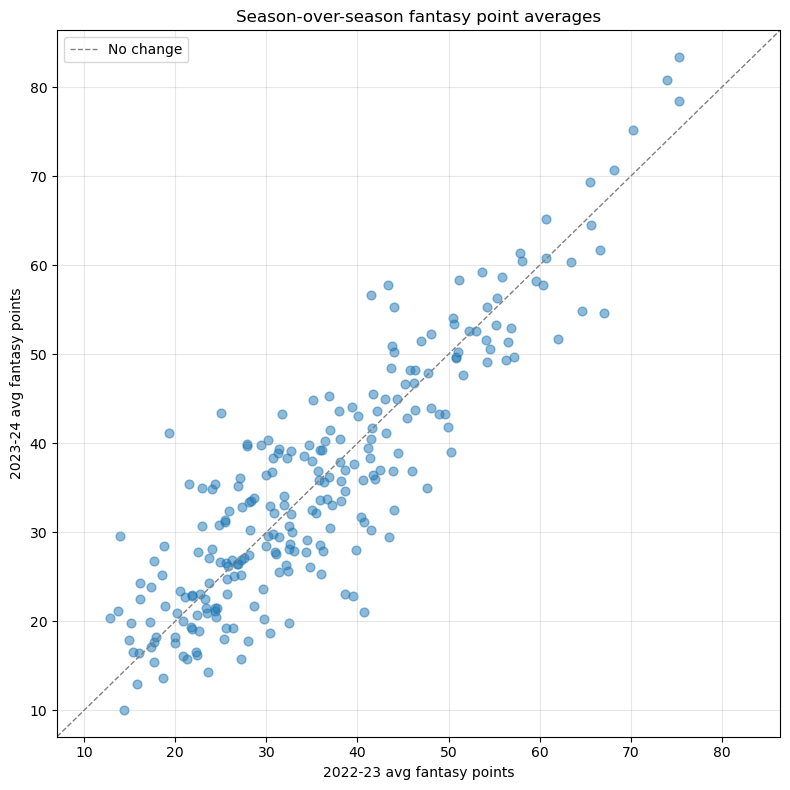

In [28]:
# Visualizing the season-over-season relationship.
#
# The diagonal line is "no change." Points above it improved, points below declined.
# This plot is the baseline the model has to beat: if last season's average alone
# explains most of next season's, any added feature has to earn its place.

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(merged['avg_fantasy_points_2223'], merged['avg_fantasy_points_2324'],
           alpha=0.5, s=40)

lims = [
    min(merged['avg_fantasy_points_2223'].min(), merged['avg_fantasy_points_2324'].min()) - 3,
    max(merged['avg_fantasy_points_2223'].max(), merged['avg_fantasy_points_2324'].max()) + 3
]
ax.plot(lims, lims, linestyle='--', color='gray', linewidth=1, label='No change')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('2022-23 avg fantasy points')
ax.set_ylabel('2023-24 avg fantasy points')
ax.set_title('Season-over-season fantasy point averages')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

### **Visualization Interpretation**

The two seasons correlate at 0.889 meaning last season's average alone explains roughly 79% of
next season's variance. That is the bar: "next season equals last season" is already a
strong prediction, so any model has to beat it to justify existing.

The value is not in the tight diagonal cluster, it's in the points far off it. Those are
the players whose production changed significantly. Above the line are the breakouts worth
targeting; below are the busts to avoid.

That creates a problem worth naming now. The dense mid-tier cluster dominates the fit, so a
model optimizing overall R² gets rewarded for nailing the predictions that don't matter for
a draft and barely penalized for missing the movers. Evaluation will need to target large
movers and high producers specifically, not just aggregate fit.



---

# Part 4 Summary: Season-over-Season Dataset

- Merged the two filtered seasons on `PLAYER_ID` using an inner join
- Kept `games_played` and `avg_minutes` from both seasons as separate suffixed columns
 rather than averaging them, preserving the signal in the year-over-year gap
- Inspected which players dropped out of the merge to confirm the losses were genuine
 absences rather than join failures
- Measured the raw correlation between the two seasons' fantasy averages, which
 establishes the baseline any model needs to improve on

---

# Part 5: Feature Engineering

## Overview
The dataset currently has one meaningful predictor: a player's 2022-23 fantasy average.
The scatter plot in Part 4 showed that alone correlates at 0.889 with 2023-24 output, which
means most of what there is to know is already known. This section adds underlying
statistical detail to test whether anything predicts next-season production *beyond* what
last season's average already tells us.

That "beyond" is the entire question. A feature that merely restates last season's
production, total points scored, total rebounds, adds nothing, because it is already
baked into the fantasy average. The features worth having are ones that describe *how* a
player produced, not *how much*, since the "how" is what signals whether the production is
about to change.

## Step 0: Establish the baseline before adding anything
Before engineering a single feature, fit a one-variable regression predicting 2023-24
fantasy average from 2022-23 fantasy average alone. Whatever R² that produces is the number
every subsequent version of the model must beat. Without it there is no way to tell whether
a feature helped or just added complexity.

## Candidate features
Grouped by the hypothesis each one tests:

**Efficiency, is the production sustainable?**
- True shooting percentage (TS%), accounts for 3PT and FT value, unlike raw FG%
- Free throw rate (FTA per FGA), proxy for rim pressure and drawn contact
- Turnover rate (TOV per possession-ish proxy)

**Role and opportunity, is the workload growing or shrinking?**
- Usage proxy (FGA + 0.44×FTA + TOV, per minute)
- Minutes per game, and minutes trend within the season (first half vs. second half)
- Games started, if available

**Skill signals that may not show up in volume yet**
- Stock rate (STL + BLK per minute), defensive activity, often stable year to year
- Assist rate per minute, playmaking role independent of scoring volume
- Three-point attempt rate, captures shift toward modern high-value shot profile

**Context**
- Age, the single most established predictor of directional change in the literature.
 Young players trend up, players past ~30 trend down. This may be the most valuable
 feature in the set, and it is not derivable from the game logs; it requires a separate
 API call.

## The one rule that cannot be broken
**Every feature must be computed from 2022-23 data only.** The target is 2023-24 fantasy
average. Any feature that touches 2023-24, including 2023-24 minutes, games played, or
team, leaks the answer into the inputs and produces a model that looks excellent and
predicts nothing. The `avg_minutes_2324` and `games_played_2324` columns currently in the
merged dataframe exist for the drop-analysis in Part 4 and must be excluded from the
feature matrix.

## How features will be judged
Not by whether they are statistically significant on their own, most basketball stats
correlate with fantasy points, because fantasy points are made of basketball stats. The
test is whether adding a feature improves out-of-sample prediction over the baseline. Any
feature that does not is dropped, and the fact that it did not is itself a finding worth
documenting.

## Steps in this section
1. Fit and record the one-feature baseline
2. Compute per-player 2022-23 rate statistics from the game logs
3. Pull player ages and join them in
4. Check feature correlations against each other (basketball stats are heavily
 collinear, usage, minutes, and volume all move together)
5. Assemble the final feature matrix, verified to contain no 2023-24 information

In [29]:
# Importing the libraries for linear regression and evaluation metrics and running a baseline model using 2022-23 fantasy points to predict 2023-24 fantasy points.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

x = merged[['avg_fantasy_points_2223']]
y = merged['avg_fantasy_points_2324']

mock_model = LinearRegression()
mock_model.fit(x, y)

predictions = mock_model.predict(x)

mock_model_r2 = r2_score(y, predictions)
mock_model_mae = mean_absolute_error(y, predictions)

print(f"Mock Model R²:  {mock_model_r2:.3f}")
print(f"Mock Model MAE: {mock_model_mae:.2f} fantasy points")

print(f"Slope:     {mock_model.coef_[0]:.3f}")
print(f"Intercept: {mock_model.intercept_:.2f}")

Mock Model R²:  0.791
Mock Model MAE: 5.02 fantasy points
Slope:     0.910
Intercept: 3.09


---

**Interpreting the Results:**

- The Baseline R^2 of 0.791 suggests that last season's average alone explains 79% of the variance in next season's fantasy average. 

- The baseline MAE(Mean Absolute Error) of 5.02 is the number I want to focus and optimize. This means on average our prediction is within 5 points of the actual value. 
- The slope of 0.910 and intercept of 3.09 together capture regression to the mean. 
 Because the slope is below 1, extreme seasons get pulled toward the middle: applying the
 model by hand, a 20 FP/game player is predicted up to 21.3, while a 60 FP/game player is
 predicted down to 57.7. The crossover point where a player is predicted to repeat exactly
 is around 34 FP/game, roughly the league-average output for this player pool. 
- The practical takeaway: the model already encodes that players coming off career years
 tend to be overvalued, and players coming off down years undervalued. This is a real
 draft edge sitting in a two-parameter regression, and it's the baseline any added feature
 has to improve on.
---



**Why the slope is below 1: regression to the mean.**

A slope of exactly 1 would mean every player is predicted to repeat last season exactly,
no pull in either direction. The fitted slope of 0.910 is below 1, and that gap is
regression to the mean showing up in the data.

The reason it happens: any single season is a mix of true ability and luck. Extreme seasons
tend to carry extreme luck, a career year usually pairs real skill with a hot shooting
stretch, unusual health, and a favorable role. Ability carries over to next season; luck
doesn't. So the extremes get pulled back toward the average as the luck washes out, and
0.910 is this dataset's estimate of how strong that pull is.

The name comes from Francis Galton, who studied height in the 1880s and noticed that tall
fathers had sons who were tall but closer to average than they were. He called it
"regression toward mediocrity," and the term is why this entire method is called
"regression" today.

One caveat: this is a statistical tendency across the whole population, not a rule about any
individual. A young player whose breakout came from a genuine jump in role isn't "due" to
regress the way an aging player who shot well above his career norm is. Separating those two
cases is part of what age and efficiency features are meant to test in Part 5.

---

In [30]:
# Splitting the data into training and testing sets for model evaluation.

from sklearn.model_selection import train_test_split

X = merged[['avg_fantasy_points_2223']]
y = merged['avg_fantasy_points_2324']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training players: {len(X_train)}")
print(f"Test players:     {len(X_test)}")

Training players: 194
Test players:     49


In [31]:
# Training a linear regression model on the training set and evaluating it on the test set.

model_v1 = LinearRegression()
model_v1.fit(X_train, y_train)

predictions = model_v1.predict(X_test)

trained_v1_r2 = r2_score(y_test, predictions)
trained_v1_mae = mean_absolute_error(y_test, predictions)

print(f"Trained Model R²:  {trained_v1_r2:.3f}")
print(f"Trained Model MAE: {trained_v1_mae:.2f} fantasy points")

print(f"Slope:     {model_v1.coef_[0]:.3f}")
print(f"Intercept: {model_v1.intercept_:.2f}")

print(" ")

print("A decline in R² and an increase in MAE on the test set compared to the baseline was expected the baseline model was training and testing on the same sample.")
print("The results from this test is what will be used to compare against future models that incorporate additional features beyond just the 2022-23 fantasy points.")

Trained Model R²:  0.744
Trained Model MAE: 5.73 fantasy points
Slope:     0.915
Intercept: 2.82
 
A decline in R² and an increase in MAE on the test set compared to the baseline was expected the baseline model was training and testing on the same sample.
The results from this test is what will be used to compare against future models that incorporate additional features beyond just the 2022-23 fantasy points.


# Part 5.1: Adding Age as a Feature

## Why age
Age is the single most established predictor of directional change in player production.
Young players tend to improve as they develop; players past their late twenties tend to
decline as athleticism fades. This is exactly the kind of signal the baseline model lacks, 
last season's average alone treats a 22-year-old and a 33-year-old with identical stats as
identical bets, when in reality one is far more likely to rise and the other to fall. Age is
also directly relevant to the regression-to-the-mean effect found in the baseline: it helps
separate a young player whose breakout is real from an older player whose career year is
likely to regress.

## Problem 1: The game logs don't contain age
The `PlayerGameLogs` endpoint returns box score stats but no birthdate or age. Age has to
come from a different endpoint, `CommonPlayerInfo`, which returns a player's bio information.

## Problem 2: That endpoint works one player at a time
`CommonPlayerInfo` takes a single `PLAYER_ID` and returns that one player's info. With ~247
players in the dataset, that means ~247 separate API calls. Three issues come with that:

- **Rate limiting.** Firing hundreds of requests in a tight loop will get throttled or
 blocked. Solution: pause briefly (`time.sleep(0.6)`) between calls to stay under the
 limit.
- **Occasional failures.** Across hundreds of calls, some will fail (timeouts, hiccups).
 Without handling, one failure at player 173 kills the whole loop. Solution: wrap each call
 in try/except, record failures, and keep going.
- **Repeated runs.** Re-fetching 247 players every time the notebook restarts is slow and
 unnecessary. Solution: fetch once, cache the result to a CSV, and load from that CSV on
 future runs instead of hitting the API again.

## Problem 3: Age needs a fixed reference point
A player's age changes during a season, so "age" is ambiguous without a reference date.
Because age is a feature in the **2022-23** feature set (used to predict 2023-24), it is
computed as of the start of the 2022-23 season (October 18, 2022). Using the target
season's date instead would misrepresent how old the player was when the feature-season
stats were produced.

## Process
1. Test the `CommonPlayerInfo` fetch on 5 players to confirm the endpoint and field name
2. Run the full loop with rate-limiting and error handling, collecting `{player_id:
 birthdate}` pairs in a dictionary
3. Cache the results to CSV so the API isn't called on every notebook run
4. Convert birthdate to age as of October 18, 2022
5. Join age onto the merged dataframe as a new feature
6. Refit the model with age added and compare the test R² and MAE against the baseline
 (0.744 / 5.73) to see whether age actually improves out-of-sample prediction

In [32]:
# Importing the necessary libraries

from nba_api.stats.endpoints import commonplayerinfo
import time
import os

# Test on 5 players first, confirm the endpoint works and we're pulling the right field
test_ids = merged['PLAYER_ID'].head(5).tolist()
test_results = {}

for pid in test_ids:
    try:
        info = commonplayerinfo.CommonPlayerInfo(player_id=pid).get_data_frames()[0]
        name = info['DISPLAY_FIRST_LAST'].iloc[0]
        birthdate = info['BIRTHDATE'].iloc[0]
        test_results[pid] = (name, birthdate)
    except Exception as e:
        print(f"Failed for {pid}: {e}")
    time.sleep(0.6)

for pid, (name, birthdate) in test_results.items():
    print(f"{pid}  {name:<25} {birthdate}")

print(" ")
print("This test shows the endpoint works and we're pulling the right field")
print("In addition, I double checked the birthdates to make sure the data is accurate.")

2544  LeBron James              1984-12-30T00:00:00
101108  Chris Paul                1985-05-06T00:00:00
200768  Kyle Lowry                1986-03-25T00:00:00
200782  P.J. Tucker               1985-05-05T00:00:00
201142  Kevin Durant              1988-09-29T00:00:00
 
This test shows the endpoint works and we're pulling the right field
In addition, I double checked the birthdates to make sure the data is accurate.


In [33]:
CACHE_FILE = 'player_birthdates.csv'

if os.path.exists(CACHE_FILE):
    # Already fetched, load from disk instead of hitting the API again
    birthdates_df = pd.read_csv(CACHE_FILE)
    print(f"Loaded {len(birthdates_df)} birthdates from cache")
else:
    all_ids = merged['PLAYER_ID'].tolist()
    birthdates = {}
    failures = []

    for i, pid in enumerate(all_ids):
        try:
            info = commonplayerinfo.CommonPlayerInfo(player_id=pid).get_data_frames()[0]
            birthdates[pid] = info['BIRTHDATE'].iloc[0]
        except Exception as e:
            failures.append(pid)
            print(f"Failed for {pid}: {e}")
        time.sleep(0.6)

        # Progress marker every 25 players so a 2-minute run isn't a silent black box
        if (i + 1) % 25 == 0:
            print(f"  {i + 1}/{len(all_ids)} done")

    birthdates_df = pd.DataFrame(
        list(birthdates.items()), columns=['PLAYER_ID', 'BIRTHDATE']
    )
    birthdates_df.to_csv(CACHE_FILE, index=False)
    print(f"\nFetched {len(birthdates_df)} birthdates, {len(failures)} failures")
    if failures:
        print(f"Failed IDs: {failures}")

Loaded 243 birthdates from cache


In [34]:
# Double checking all the players from the merged dataset are present in the birthdates dataset. If any are missing, it will be flagged here.
print(f"Rows in merged: {len(merged)}")
print(f"Birthdates fetched: {len(birthdates_df)}")
print(f"Match: {len(merged) == len(birthdates_df)}")

Rows in merged: 243
Birthdates fetched: 243
Match: True


In [35]:
# Reference date: start of the 2022-23 season (the feature season).
# Age is computed relative to this so it represents how old the player was
# when the feature-season stats were produced, not their current age.
reference_date = pd.Timestamp('2022-10-18')

birthdates_df['BIRTHDATE'] = pd.to_datetime(birthdates_df['BIRTHDATE'])

# Age in years = days between birthdate and reference, divided by 365.25
# (.25 accounts for leap years)
birthdates_df['age'] = (
    (reference_date - birthdates_df['BIRTHDATE']).dt.days / 365.25
)

print(birthdates_df[['PLAYER_ID', 'BIRTHDATE', 'age']].head())
print()
print(birthdates_df['age'].describe())
print()
print("The Distribution of the ages of the players in the dataset make sense and are consistent with the ages of NBA players in general.")

   PLAYER_ID  BIRTHDATE        age
0       2544 1984-12-30  37.798768
1     101108 1985-05-06  37.451061
2     200768 1986-03-25  36.566735
3     200782 1985-05-05  37.453799
4     201142 1988-09-29  34.050650

count    243.000000
mean      26.337403
std        4.176137
min       18.915811
25%       23.166324
50%       25.708419
75%       29.197810
max       37.798768
Name: age, dtype: float64

The Distribution of the ages of the players in the dataset make sense and are consistent with the ages of NBA players in general.


In [36]:
# Identify the youngest and oldest players

youngest = birthdates_df.loc[birthdates_df['age'].idxmin()]
oldest = birthdates_df.loc[birthdates_df['age'].idxmax()]
print(f"Youngest: {youngest['PLAYER_ID']}, age {youngest['age']:.1f}, born {youngest['BIRTHDATE'].date()}")
print(f"Oldest:   {oldest['PLAYER_ID']}, age {oldest['age']:.1f}, born {oldest['BIRTHDATE'].date()}")

Youngest: 1631105, age 18.9, born 2003-11-18
Oldest:   2544, age 37.8, born 1984-12-30


In [37]:
# Join the birthdates to the merged dataset
merged = merged.merge(
    birthdates_df[['PLAYER_ID', 'age']],
    on='PLAYER_ID',
    how='left'
)

# Confirm no player lost their age in the join
print(f"Rows: {len(merged)}, missing age: {merged['age'].isna().sum()}")

Rows: 243, missing age: 0


In [38]:
# Viewing the youngest player in the dataset to make sure it was a rookie that performed well enough to qualify in 2022-23.

print(merged[merged['PLAYER_ID'] == 1631105][['player_name', 'age', 'avg_fantasy_points_2223']])
print()
print("Jalen Duren is a notable player and he did perform well enough to qualify in 2022-23, so this makes sense.")

     player_name        age  avg_fantasy_points_2223
236  Jalen Duren  18.915811                31.731343

Jalen Duren is a notable player and he did perform well enough to qualify in 2022-23, so this makes sense.


### Prediction: will age improve the model?

My guess is that **test R² will dip slightly**, for three reasons:

1. **Age vs. production isn't linear.** Production tends to follow a bell curve, rising from
 ~19 to a peak in the late 20s, then declining. A linear model fits a single straight slope
 through that curve, so the early rise and late decline partly cancel out and age looks
 weaker than it really is.

2. **Restricted range.** Every player here already cleared the minutes filter, so they're
 roughly the top half of the league. The clearest "old = declining" cases, vets who lost
 their rotation spot, were already filtered out (the Part 4 role-loss group). That
 survivorship bias removes age's strongest signal before it can be measured.


I expect age would be far more predictive if tested across the *entire* NBA player base,
where the age range is wider and declining players aren't filtered out.

In [39]:
# v1 (baseline) and v2 (with age) each need their own feature matrix.
# Same split indices via the same random_state, so the comparison stays fair.

y = merged['avg_fantasy_points_2324']

# v1 features: last season's average only
X_v1 = merged[['avg_fantasy_points_2223']]
X_v1_train, X_v1_test, y_train, y_test = train_test_split(
    X_v1, y, test_size=0.2, random_state=42
)

# v2 features: average + age
X_v2 = merged[['avg_fantasy_points_2223', 'age']]
X_v2_train, X_v2_test, _, _ = train_test_split(
    X_v2, y, test_size=0.2, random_state=42
)

# Refit both here so the cell is self-contained
model_v1 = LinearRegression().fit(X_v1_train, y_train)
model_v2 = LinearRegression().fit(X_v2_train, y_train)

v1_train_r2 = r2_score(y_train, model_v1.predict(X_v1_train))
v1_test_r2  = r2_score(y_test,  model_v1.predict(X_v1_test))
v1_test_mae = mean_absolute_error(y_test, model_v1.predict(X_v1_test))
v1_train_mae = mean_absolute_error(y_train, model_v1.predict(X_v1_train))


v2_train_r2 = r2_score(y_train, model_v2.predict(X_v2_train))
v2_test_r2  = r2_score(y_test,  model_v2.predict(X_v2_test))
v2_test_mae = mean_absolute_error(y_test, model_v2.predict(X_v2_test))
v2_train_mae = mean_absolute_error(y_train, model_v2.predict(X_v2_train))

print("v1, baseline (last season's average only)")
print(f"  train R²: {v1_train_r2:.3f}   test R²: {v1_test_r2:.3f}   test MAE: {v1_test_mae:.2f}    trained MAE: {v1_train_mae:.2f}")
print()
print("v2, with age added")
print(f"  train R²: {v2_train_r2:.3f}   test R²: {v2_test_r2:.3f}   test MAE: {v2_test_mae:.2f}    trained MAE: {v2_train_mae:.2f}")
print(f"  age coef: {model_v2.coef_[1]:.3f}")

v1 — baseline (last season's average only)
  train R²: 0.801   test R²: 0.744   test MAE: 5.73    trained MAE: 4.82

v2 — with age added
  train R²: 0.827   test R²: 0.766   test MAE: 5.77    trained MAE: 4.51
  age coef: -0.541


---
## Age Feature Synopsis:

1. **My prediction was wrong, test R² rose instead of dipping** (0.744 → 0.766). The
 evidence that age genuinely helped is the test R² improving *without* the train-test gap
 widening much (0.057 → 0.061), which means age is adding real signal rather than noise the
 model overfits to.

2. **But it's a marginal, mixed result, not a clean win.** Test MAE actually nudged the wrong
 way (5.73 → 5.77). The train metrics both improved (train R² up, train MAE down 4.82 →
 4.51), but that doesn't count as evidence, adding *any* feature lets a model fit the
 training data tighter, signal or not. Only the test scores matter, and they disagree with
 each other. So the honest verdict is that age improves the model slightly.

3. **The negative age coefficient (-0.541) is the key insight.** It means that holding last
 season's average constant, each additional year of age predicts about half a fantasy point
 less next season. This is the linear model catching the downhill (right) side of the bell
 curve I predicted earlier, as players age, they decline. Half a point per year isn't a lot,
 but the sign is correct and the effect is real.

4. **Caveat: the test set is only 49 players.** A 0.022 R² gain and a 0.04 MAE change on that
 few data points are small enough to be partly noise from which players landed in the split.
 The direction (age helps a little) is trustworthy; the exact numbers are not worth defending
 to three decimals. Cross-validation later will give a more stable estimate.

In [40]:
# v3: add age² so the model can fit a CURVE in age, not just a straight line.
# This directly tests the bell-curve hypothesis,  if production peaks in the late 20s
# and falls off on both ends, a squared term lets the model bend to capture that,
# where the linear age term could only fit the dominant downhill half.

merged['age_squared'] = merged['age'] ** 2

y = merged['avg_fantasy_points_2324']

X_v3 = merged[['avg_fantasy_points_2223', 'age', 'age_squared']]
X_v3_train, X_v3_test, y_train, y_test = train_test_split(
    X_v3, y, test_size=0.2, random_state=42
)

model_v3 = LinearRegression().fit(X_v3_train, y_train)

v3_train_r2  = r2_score(y_train, model_v3.predict(X_v3_train))
v3_test_r2   = r2_score(y_test,  model_v3.predict(X_v3_test))
v3_train_mae = mean_absolute_error(y_train, model_v3.predict(X_v3_train))
v3_test_mae  = mean_absolute_error(y_test,  model_v3.predict(X_v3_test))

print("v3, with age + age²")
print(f"  train R²: {v3_train_r2:.3f}   test R²: {v3_test_r2:.3f}")
print(f"  train MAE: {v3_train_mae:.2f}   test MAE: {v3_test_mae:.2f}")
print(f"  age coef: {model_v3.coef_[1]:.3f}   age² coef: {model_v3.coef_[2]:.3f}")
print()
print("Comparison (test set):")
print(f"  v1 baseline:   R² 0.744   MAE 5.73")
print(f"  v2 +age:       R² 0.766   MAE 5.77")
print(f"  v3 +age+age²:  R² {v3_test_r2:.3f}   MAE {v3_test_mae:.2f}")

v3 — with age + age²
  train R²: 0.827   test R²: 0.765
  train MAE: 4.51   test MAE: 5.77
  age coef: -1.350   age² coef: 0.015

Comparison (test set):
  v1 baseline:   R² 0.744   MAE 5.73
  v2 +age:       R² 0.766   MAE 5.77
  v3 +age+age²:  R² 0.765   MAE 5.77


## Decision to Drop Age²:

- Age² had essentially no impact, test R² went slightly the wrong way (0.766 → 0.765) and MAE was unchanged.
- The coefficient signs are the key tell: age is negative and age² is positive, which is a right-side-up U, the *opposite* of a bell curve. Since that's not a real aging effect, the model is just fitting noise.
- The bell curve I hypothesized is real in the full NBA population, but the minutes filter removed the young-riser and old-decliner extremes, so there's no curve left in this sample for age² to latch onto.

**Age² is dropped from all subsequent models. v2 (average + age) remains the current best.**

----
## Part 5.2: Advanced Rate Stats, the "Sneaky Stats" Layer

This is the core hypothesis of the project. The baseline showed that last season's fantasy
average alone predicts ~74% of next season's variance, and age added a small amount on top.
The question now is whether *how* a player produced, the style and quality behind the raw
output, predicts next-season change beyond *how much* they produced.

### The hypothesis
Two players can average the same fantasy points by very different means. One scores
efficiently on low volume with strong defensive activity; another puts up empty volume on
poor shooting. The raw average treats them identically, but their underlying profiles might
signal different futures, the efficient player's production may be more sustainable, the
high-usage-low-efficiency player's more likely to regress. Rate stats are how that
difference gets measured.

### Candidate features (all computed from 2022-23 only)
- **True Shooting % (TS%)**, scoring efficiency accounting for 3PT and FT value
- **Free throw rate (FTA/FGA)**, rim pressure and drawn contact
- **Three-point attempt rate (FG3A/FGA)**, shot profile / modern spacing
- **Stock rate per 36 (STL+BLK)**, defensive activity, tends to be stable year to year
- **Assist rate per 36**, playmaking role, independent of scoring
- **Turnover rate per 36**, ball security
- **Usage proxy per 36 (FGA + 0.44×FTA + TOV)**, how much offense runs through the player

### Two methodological choices baked in here
1. **Rates are volume-weighted :** raw makes/attempts are summed across the season,
 then divided once, not averaged per game. Averaging per-game percentages would let a
 3-shot night count as heavily as a 25-shot night, distorting the season figure.
2. **Counting stats are normalized per 36 minutes:** this expresses each stat as "per full
 game's worth of minutes," so a starter and a bench player can be compared on the same
 footing rather than raw totals that just reflect playing time.

### How each feature will be judged
The same bar as age: does adding it improve *test* R² over the current best model (v2, at
0.766)? A statistically significant coefficient isn't enough, most basketball stats
correlate with fantasy points because fantasy points are made of basketball stats. The test
is out-of-sample improvement. Features that don't clear it get dropped and documented as
negative results, the same way age² was.

In [41]:
# Aggregate raw season TOTALS per player from the 2022-23 game logs.
# Summing counting stats (not averaging per-game rates) so that rate stats computed
# from these are volume-weighted correctly, Option A.
#
# This is separate from summarize_season() because that function intentionally kept only
# games/minutes/fantasy points. Here we need the underlying box-score components.

season_totals_2223 = df_2223.groupby('PLAYER_ID').agg(
    games=('GAME_ID', 'count'),
    total_min=('MIN', 'sum'),
    total_pts=('PTS', 'sum'),
    total_fgm=('FGM', 'sum'),
    total_fga=('FGA', 'sum'),
    total_ftm=('FTM', 'sum'),
    total_fta=('FTA', 'sum'),
    total_fg3m=('FG3M', 'sum'),
    total_fg3a=('FG3A', 'sum'),
    total_reb=('REB', 'sum'),
    total_ast=('AST', 'sum'),
    total_stl=('STL', 'sum'),
    total_blk=('BLK', 'sum'),
    total_tov=('TOV', 'sum'),
).reset_index()

print(f"Players: {len(season_totals_2223)}")
season_totals_2223.head()

Players: 539


,PLAYER_ID,games,total_min,total_pts,total_fgm,total_fga,total_ftm,total_fta,total_fg3m,total_fg3a,total_reb,total_ast,total_stl,total_blk,total_tov
0,2544,55,1953.940000,1590,609,1219,251,327,121,377,457,375,50,32,178
1,2617,7,72.118333,27,10,29,4,5,3,9,11,0,1,2,1
2,2738,8,112.563333,17,7,15,2,3,1,9,17,19,4,3,9
3,101108,59,1888.635000,819,294,668,133,160,98,261,251,524,91,22,114
4,200752,56,815.568333,293,109,287,42,49,33,130,163,57,19,18,37


In [42]:
# Build rate stats from season totals (Sum then divide).
# Counting stats normalized per-36-minutes so bench and starter compare fairly.

rates = season_totals_2223.copy()

# Efficiency and shot-profile ratios (no per-36 needed, already unitless ratios)
rates['ts_pct'] = rates['total_pts'] / (2 * (rates['total_fga'] + 0.44 * rates['total_fta']))
rates['ft_rate'] = rates['total_fta'] / rates['total_fga']
rates['fg3a_rate'] = rates['total_fg3a'] / rates['total_fga']

# Per-36 counting stats
per36 = 36 / rates['total_min']
rates['stock_per36'] = (rates['total_stl'] + rates['total_blk']) * per36
rates['ast_per36'] = rates['total_ast'] * per36
rates['tov_per36'] = rates['total_tov'] * per36
rates['usage_per36'] = (rates['total_fga'] + 0.44 * rates['total_fta'] + rates['total_tov']) * per36

feature_cols = ['ts_pct', 'ft_rate', 'fg3a_rate', 'stock_per36', 'ast_per36', 'tov_per36', 'usage_per36']

print(rates[['PLAYER_ID'] + feature_cols].describe())
print()
print("Three issues to flag from the above summary:")
print("1. The counts don't match Some are 537 and the rest are 539 players. This is likely due to a player taking zeo FGA's all season and it produces a NaN result which the describe() function ignores.")
print("2. A few key stats have a minimum of 0, This is likely due to a player logging garbage time minutes and doing no meaningful work during playing time.")
print("3. The per36 stats have extreme outliers. For example 'stock_36' and 'tov_36' having maxes of 34 and 14 respectivly does not make sense.")
print("   I think this is because a player who logged 3 total minutes and happened to get 1 steal extrapolates to an absurd per-36 rate.")

print(" ")
print("Good news is that all these red flags have the same core reasoining and the filter should resolve all of them.")

          PLAYER_ID      ts_pct     ft_rate   fg3a_rate  stock_per36  \
count  5.390000e+02  537.000000  537.000000  537.000000   539.000000   
mean   1.305387e+06    0.562684    0.251104    0.401785     1.865771   
std    6.002138e+05    0.097377    0.181995    0.218853     1.635744   
min    2.544000e+03    0.000000    0.000000    0.000000     0.000000   
25%    1.626168e+06    0.523828    0.142857    0.260684     1.278600   
50%    1.629139e+06    0.567072    0.228571    0.408935     1.667316   
75%    1.630532e+06    0.609339    0.323077    0.547421     2.212897   
max    1.641645e+06    1.063830    2.000000    1.000000    34.015748   

        ast_per36   tov_per36  usage_per36  
count  539.000000  539.000000   539.000000  
mean     3.393226    1.935938    15.506368  
std      2.087044    1.232330     4.892926  
min      0.000000    0.000000     0.000000  
25%      1.885967    1.286123    12.045311  
50%      2.890853    1.779425    14.708375  
75%      4.488476    2.337831    17.

In [43]:
merged = merged.merge(rates[['PLAYER_ID'] + feature_cols], on='PLAYER_ID', how='left')

print(f"Rows: {len(merged)}, any missing features: {merged[feature_cols].isna().sum().sum()}")
print()
print(merged[feature_cols].describe())

print(" ")
print("Success! The features have been merged into the dataset and the red flags have been resolved.")

Rows: 243, any missing features: 0

           ts_pct     ft_rate   fg3a_rate  stock_per36   ast_per36  \
count  243.000000  243.000000  243.000000   243.000000  243.000000   
mean     0.585360    0.260216    0.395919     1.784002    3.867619   
std      0.046756    0.117926    0.192790     0.671607    2.151722   
min      0.454714    0.042929    0.000000     0.668965    1.123452   
25%      0.553036    0.169034    0.281699     1.316913    2.145248   
50%      0.586156    0.246073    0.408385     1.667316    3.472883   
75%      0.614759    0.326891    0.514403     2.125100    5.061874   
max      0.738560    0.625000    0.845960     5.115515   11.185152   

        tov_per36  usage_per36  
count  243.000000   243.000000  
mean     2.034498    17.135585  
std      0.769429     5.037581  
min      0.686435     5.233350  
25%      1.498437    13.522216  
50%      1.933566    16.801983  
75%      2.475045    20.892904  
max      4.376327    33.154765  
 
Success! The features have been me

### Before adding these features to the model I want to test for Multicollinearity. Basketball stats at its core are already Colinear, <br> I just want to spot out some major red flags. I am thinking Usage rate with either turnovers or assists will get flagged.
 

In [44]:
# Running a correlation matrix to test for any multicollinearity issues.
# Any correlation above +/- 0.7 is a red flag and should be investigated further.

corr = merged[feature_cols].corr()
print(corr.round(2))

print(" ")
print("Turnovers and Usage gets flagged at .76")
print("Assists and Turnovers doesnt get flagged at .67, but it is something to watch out for.")

print(" ")
print("Turnovers and Usage makes sense because someone who handles the ball more has more opportunities to turn it over.")
print("Assists and Turnovers makes sense because a playermaker may rack assists and turnovers together.")

             ts_pct  ft_rate  fg3a_rate  stock_per36  ast_per36  tov_per36  \
ts_pct         1.00     0.46      -0.31         0.27      -0.14      -0.03   
ft_rate        0.46     1.00      -0.61         0.20       0.11       0.40   
fg3a_rate     -0.31    -0.61       1.00        -0.38      -0.11      -0.34   
stock_per36    0.27     0.20      -0.38         1.00      -0.08      -0.07   
ast_per36     -0.14     0.11      -0.11        -0.08       1.00       0.67   
tov_per36     -0.03     0.40      -0.34        -0.07       0.67       1.00   
usage_per36   -0.03     0.39      -0.22        -0.20       0.45       0.76   

             usage_per36  
ts_pct             -0.03  
ft_rate             0.39  
fg3a_rate          -0.22  
stock_per36        -0.20  
ast_per36           0.45  
tov_per36           0.76  
usage_per36         1.00  
 
Turnovers and Usage gets flagged at .76
Assists and Turnovers doesnt get flagged at .67, but it is something to watch out for.
 
Turnovers and Usage makes se

### The correlation matrix only shows pairs. It can miss multicollinearity spread across three or more features. <br> The proper tool for that is VIF (Variance Inflation Factor), <br> which measures how well each feature can be predicted from all the others together, not just one at a time.

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF measures how well each feature can be predicted from ALL the other features combined.
# A feature that's redundant given the others gets a high VIF.
#
# Rules of thumb: VIF < 5 is fine, 5-10 is a warning, >10 is serious multicollinearity.
# The constant column is added because VIF math requires an intercept term; we ignore its VIF.

X_vif = add_constant(merged[feature_cols])

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Drop the constant row from display, its VIF isn't meaningful
print(vif_data[vif_data['feature'] != 'const'].to_string(index=False))

    feature      VIF
     ts_pct 1.407958
    ft_rate 2.171307
  fg3a_rate 1.877537
stock_per36 1.331942
  ast_per36 1.963789
  tov_per36 3.946830
usage_per36 2.637662


## Multicollinearity Check: Correlation + VIF

Before modeling with the seven rate stats, I checked whether any were redundant with each
other. Redundant features make linear regression coefficients unstable, which would
undermine the whole point of the "sneaky stats" thesis, interpreting *which* stats matter.

**Correlation matrix** flagged one pair above the 0.7 rule of thumb: usage_per36 ↔
tov_per36 at 0.76, with ast_per36 ↔ tov_per36 close behind at 0.67. This matched the
basketball logic, usage, turnovers, and assists all track "how much a player handles the
ball," so they move together.

**VIF told a calmer story.** A pairwise correlation only shows two features at a time; VIF
measures how redundant each feature is against *all* the others combined, which is the real
test. Every feature came back under 5, the highest was tov_per36 at 3.95, then usage at
2.64. Nothing reached the warning zone.

The two diagnostics disagreeing is the useful lesson: a 0.76 pairwise correlation looks
alarming but is only ~58% shared variance, and once the full math is done, no feature is
redundant enough to matter. This is why VIF is the right tool and "correlation > 0.7" is
just a rough flag, not a rule.

**Decision: keep all seven features.** None is collinear enough to drop. Note this clears
them only for *interpretability*, it says nothing about whether they actually improve
prediction, which is the next test.

In [46]:
# v4: add all seven advanced rate stats on top of v2 (average + age).
# Same train/test split (random_state=42) so the comparison against v2's 0.766 is fair.

v4_features = ['avg_fantasy_points_2223', 'age',
               'ts_pct', 'ft_rate', 'fg3a_rate',
               'stock_per36', 'ast_per36', 'tov_per36', 'usage_per36']

X_v4 = merged[v4_features]
y = merged['avg_fantasy_points_2324']

X_v4_train, X_v4_test, y_train, y_test = train_test_split(
    X_v4, y, test_size=0.2, random_state=42
)

# your turn: fit the model, score train + test R² and MAE, compare against v2 (0.766 / 5.77)
model_v4 = LinearRegression().fit(X_v4_train, y_train)

v4_train_r2 = r2_score(y_train, model_v4.predict(X_v4_train))
v4_test_r2 = r2_score(y_test, model_v4.predict(X_v4_test))
v4_train_mae = mean_absolute_error(y_train, model_v4.predict(X_v4_train))
v4_test_mae = mean_absolute_error(y_test, model_v4.predict(X_v4_test))

print("v4, with age + advanced rate stats")
print(f"  train R²: {v4_train_r2:.3f}   test R²: {v4_test_r2:.3f}")
print(f"  train MAE: {v4_train_mae:.2f}  test MAE: {v4_test_mae:.2f}")
print(f"  age coef: {model_v4.coef_[1]:.3f}")
print(f"  ts_pct coef: {model_v4.coef_[2]:.3f}")
print(f"  ft_rate coef: {model_v4.coef_[3]:.3f}")
print(f"  fg3a_rate coef: {model_v4.coef_[4]:.3f}")
print(f"  stock_per36 coef: {model_v4.coef_[5]:.3f}")
print(f"  ast_per36 coef: {model_v4.coef_[6]:.3f}")
print(f"  tov_per36 coef: {model_v4.coef_[7]:.3f}")
print(f"  usage_per36 coef: {model_v4.coef_[8]:.3f}")

print(" ")
print("Comparison (test set):")
print(f"  v2: {v2_test_r2:.3f} / {v2_test_mae:.2f}")
print(f"  v4: {v4_test_r2:.3f} / {v4_test_mae:.2f}")


v4 — with age + advanced rate stats
  train R²: 0.836   test R²: 0.743
  train MAE: 4.47  test MAE: 5.98
  age coef: -0.552
  ts_pct coef: 24.782
  ft_rate coef: 0.537
  fg3a_rate coef: 3.556
  stock_per36 coef: -0.479
  ast_per36 coef: -0.355
  tov_per36 coef: 1.189
  usage_per36 coef: 0.062
 
Comparison (test set):
  v2: 0.766 / 5.77
  v4: 0.743 / 5.98


## v4 Synopsis:

Adding all seven advanced rate stats on top of v2 (average + age) **made the model worse**,
and the pattern is a textbook overfitting signature:

| Model | Train R² | Test R² | Test MAE |
|---|---|---|---|
| v2 (average + age) | 0.827 | **0.766** | **5.77** |
| v4 (+ 7 rate stats) | 0.836 | **0.743** | **5.98** |

Train R² went **up** (0.827 → 0.836) while test R² went **down** (0.766 → 0.743). That gap
widening is the definition of overfitting: the extra features gave the model more knobs to
fit the training data, and it used them to memorize noise that doesn't generalize to unseen
players. Test MAE rising alongside confirms it.

**What this means for the core thesis.** The project's central question was whether advanced
stats predict next-season fantasy output *beyond* last season's average. On this data, the
answer is no. The information those stats carry, efficiency, usage, defensive activity, is
already baked into how many fantasy points a player scored last season. A high-usage,
efficient scorer already shows up as a high fantasy average, so re-adding TS% and usage
mostly re-describes what the average already captured, plus noise.

**Why this is a real finding, not a failure.** Throwing features at a model until R² rises
is easy and meaningless. Forming a hypothesis, testing it rigorously with a held-out set,
and finding the signal was already contained in the target, with clear overfitting evidence,
 is a genuine result and a stronger one to defend.

**Caution on the coefficients.** Some coefficients look large (e.g. ts_pct at ~24.8), but
because the model is overfitting, individual coefficients are fitting training noise and are
not trustworthy. This is *not* evidence that "TS% matters a lot", the model that produced
that number performs worse than v2.

In [47]:
# Stepwise / individual feature test: add each rate stat to v2 ONE at a time,
# to check whether any single stat helps even when all seven together hurt.

rate_stats = ['ts_pct', 'ft_rate', 'fg3a_rate', 'stock_per36',
              'ast_per36', 'tov_per36', 'usage_per36']

base = ['avg_fantasy_points_2223', 'age']
y = merged['avg_fantasy_points_2324']

print(f"{'feature added':<16} {'test R²':>8} {'test MAE':>9}   vs v2 (0.766 / 5.77)")
print("-" * 55)

for stat in rate_stats:
    feats = base + [stat]
    X = merged[feats]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    m = LinearRegression().fit(X_tr, y_tr)
    r2 = r2_score(y_te, m.predict(X_te))
    mae = mean_absolute_error(y_te, m.predict(X_te))
    flag = "  <-- beats v2" if r2 > 0.766 else ""
    print(f"{stat:<16} {r2:>8.3f} {mae:>9.2f}{flag}")

feature added     test R²  test MAE   vs v2 (0.766 / 5.77)
-------------------------------------------------------
ts_pct              0.753      5.87


ft_rate             0.766      5.78  <-- beats v2
fg3a_rate           0.767      5.75  <-- beats v2
stock_per36         0.769      5.71  <-- beats v2
ast_per36           0.757      5.87
tov_per36           0.766      5.77  <-- beats v2
usage_per36         0.765      5.79


## Stepwise Test Conclusion: No Single Stat Helps Either

v4 showed all seven rate stats together hurt the model (overfitting). This test checks the
other possibility: does any *single* rate stat help when added to v2 on its own?

**Answer: no, not by any margin that's real.** Four stats nominally "beat" v2, but look at
the size of the wins:

- The best (stock_per36) improved test R² by 0.003 (0.766 → 0.769)
- ft_rate and tov_per36 came in at 0.766, identical to v2 to three decimals
- The "beats v2" flags are firing on differences smaller than the measurement noise

The test set is only 49 players. A 0.003 R² change on 49 data points is well inside the
noise floor, reshuffling the split with a different random_state would scramble these
rankings entirely. None of these is a genuine improvement; they're all statistically
indistinguishable from v2.

This is exactly why a single train/test split can't be trusted for small differences (the
49-player concern flagged back at the split stage), and why cross-validation exists. Treating
a 0.003 gain as a "finding" would be reading noise as signal.

**Combined with v4, both halves of the thesis are now closed:**
- Collectively, the advanced stats overfit and hurt performance.
- Individually, none helps beyond noise.

Advanced box-score rate stats do not add predictive signal beyond last season's fantasy
average and age, on this data.

----
# Project Summary & Conclusion

## What I set out to do
Build a model that forecasts a player's next-season fantasy average from their prior-season
stats, scored under my ESPN league's custom settings, and test whether "sneaky" advanced
stats (efficiency, usage, defensive rate stats) predict production beyond raw output.

## What I built
An end-to-end pipeline: a validated custom fantasy-scoring function, two seasons of NBA game
logs pulled and cleaned via `nba_api`, a threshold-filtered and season-over-season merged
dataset, and a series of linear regression models evaluated on a held-out test set.

## Final model
**v2: last season's fantasy average + age.** Test R² 0.766, MAE 5.77. Simple, interpretable,
and not overfit.

| Model | Features | Test R² | Test MAE |
|---|---|---|---|
| v1 baseline | last season's avg | 0.744 | 5.73 |
| **v2 (final)** | **avg + age** | **0.766** | **5.77** |
| v3 | avg + age + age² | 0.765 | 5.77 |
| v4 | avg + age + 7 rate stats | 0.743 | 5.98 |

## The key finding
**Advanced box-score rate stats do not add predictive value beyond last season's average and
age.** Added all together they overfit and hurt performance; added individually, none beat v2
by more than measurement noise. The information those stats carry is already contained in how
many fantasy points a player scored, a high-usage efficient scorer already shows up as a
high fantasy average, so re-adding TS% and usage mostly re-describes what the average already
captured.

But I think there's a deeper reason the advanced stats didn't help, and it points at the data
itself rather than the model: **box score stats probably aren't the best way to predict these
players in the first place.** They're lagging *outcome* stats, they tell you what a player
did, not the underlying skill, role, or context that produced it. I doubt NBA front offices or
the companies that project player performance are relying on last season's averages to make
decisions. The signal they use is deeper, things like how much time a player spends around
the restricted area, shot quality, defensive matchups, data that explains *why* the box score
came out the way it did. That kind of explanatory data is likely where real predictive edge
lives, and it's beyond what box score stats can offer.

This is a genuine result, not a failure. Throwing features at a model until R² rises is easy
and meaningless; forming a hypothesis, testing it with a held-out set, and finding the signal
was already in the target, with clear overfitting evidence, is the honest answer to the
question I asked.

Age was the one feature that helped. Its negative coefficient (~-0.5 pts/year) captured the
downhill side of the aging curve, though age² showed the full bell curve isn't present in a
minutes-filtered sample.

## Documented limitations
- **Survivorship bias:** the merge only keeps players who cleared the threshold in both
 seasons, so the model never trains on players whose seasons collapsed (injury, role loss).
 It will therefore skew optimistic on players about to decline.
- **Small sample:** 243 paired player-seasons, with a 49-player test set. Differences under
 ~0.01 R² are within the noise; cross-validation would give more stable estimates.
- **Box-score ceiling:** the features are lagging outcome stats. Last season's average alone
 already explains ~74% of next season, and a meaningful share of the rest (injuries, trades,
 role changes) is genuinely unpredictable from any box score.

## What I'd do differently / next
The biggest lever isn't a fancier model, it's better data. As noted above, box score stats
describe what happened, not the skill or role behind it. Player-tracking data (time in the
restricted area, shot quality, defensive matchups, on/off splits) is the kind of explanatory
signal that actually drives player projection, and it's where I'd focus a follow-up project. A
tree-based model would also be worth trying, specifically to test whether advanced stats have
*conditional* value (e.g. mattering for young players but not veterans) that a linear model
structurally can't capture. Both are their own projects.

## What I learned
Documented throughout in the Concepts Log, but the through-line: rigorous evaluation
(train/test discipline, leakage, overfitting, VIF), letting data overrule intuition (the
threshold validation, the age prediction I got wrong, the multicollinearity scare that VIF
dismissed), and the discipline to report a negative result honestly rather than torturing the
model for a better number.

----

# Debugging Log

A running record of every bug encountered during this project, how it was caught, and how
it was fixed. Kept deliberately, the diagnosis process is as much a part of the work as
the working code.

---

## Bug 1: Line Continuation Error (Silent Bug)
**Problem:** The linear fantasy points formula was split across two lines without proper
continuation syntax. Python treated the second line as a separate statement, meaning
`blocks`, `turnovers`, `ejections`, and `flagrant_fouls` were silently not being counted
in the total.

**How it was caught:** Code review before running, the formula visually looked complete
but the line break meant Python never executed the second half.

**Fix:** Wrapped the entire formula in one set of outer parentheses so Python treats it as
a single continuous expression.

---

## Bug 2: Bonus Tier Flags Passed as Parameters (Logic Error)
**Problem:** `double_doubles`, `triple_doubles`, and `quadruple_doubles` were passed in as
function parameters instead of being derived internally from the box score stats. In real
data pipelines, a dataset won't have pre-computed bonus columns, the function needs to
determine bonuses itself from the raw counting stats.

**How it was caught:** Code review, identified that the function was depending on the
caller to correctly pre-compute something the function should own.

**Fix:** Removed the bonus flags from the function signature entirely. Instead, built
internal logic using a `qualifying_stats` list and `sum()` to count how many of PTS, REB,
AST, STL, BLK hit double digits, then derived the bonus flags from that count.

---

## Bug 3: Incorrect Quadruple Double Bonus Value
**Problem:** The quadruple double bonus was coded as `+4` instead of `+100` as specified in
the league's scoring settings.

**How it was caught:** Cross-referencing the code against the documented league scoring rules.

**Fix:** Changed the quadruple double bonus to `+100`.

---

## Bug 4: Return Statement Inside Conditional Block (Indentation Error)
**Problem:** The `return fantasy_points` statement and all three bonus `if` blocks were
indented inside the `if categories_in_double_digits >= 4` block. This meant the function
only returned a value when a quadruple double occurred, all other games returned `None`.

**How it was caught:** Function returned `None` on Jokic's triple-double game. Traced back
to indentation placing the return inside the quadruple-double conditional.

**Fix:** Dedented the bonus `if` blocks and the `return` statement so they execute
regardless of which bonus tier was triggered.

---

## Bug 5: UnboundLocalError on Boolean Flags (Scope Error)
**Problem:** `double_doubles`, `triple_doubles`, and `quadruple_doubles` were defined as
`False` in the global scope but not initialized inside the function. Because Python saw
assignment to these variables inside the function (in the `if` blocks), it treated them as
local variables, but if the `if` condition was False, they were never assigned, causing an
`UnboundLocalError` when the bonus checks tried to read them.

**How it was caught:** Runtime error, 
`UnboundLocalError: cannot access local variable 'quadruple_doubles' where it is not
associated with a value`.

**Fix:** Initialized all three boolean flags to `False` at the top of the function body,
before any conditional logic, ensuring they always have a value regardless of which
conditions trigger.

---

## Bug 6: String Comparison on Dates Dropped Boundary Games
**Problem:** `GAME_DATE` arrives from the API as a string with a timestamp attached
(`'2023-04-09T00:00:00'`), not as a date. Filtering with
`df['GAME_DATE'] <= '2023-04-09'` compares two strings character by character. Since
`'2023-04-09T00:00:00'` is identical to `'2023-04-09'` up to the point where the timestamp
begins and then continues, the comparison evaluates to `False`, silently dropping every
single game played on the cutoff date.

**How it was caught:** The filtered 2022-23 data ended on April 8 despite a cutoff of
April 9. The inconsistency was visible because the two seasons' filters had been written
with slightly different cutoff padding, and only one of them looked wrong.

**Fix:** Converted `GAME_DATE` with `pd.to_datetime()` before filtering, making the
comparison date-aware. Padding the cutoff by an extra day would have masked the symptom
while leaving the underlying type error in place.

---

## Bug 7: Overwriting the Raw DataFrame Destroyed the Source Data
**Problem:** The date filter was written as `df_2223 = df_2223[...]`, reassigning the raw
DataFrame to its own filtered subset. Combined with Bug 6, this meant the April 9 games
were permanently removed from the in-memory object. Widening the date range afterward had
no effect, because the rows no longer existed to be re-included, which made the bug look
like a filter problem when it was actually a data loss problem.

**How it was caught:** Changing the end date to a much later value failed to bring back the
missing games, proving the filter wasn't the culprit.

**Fix:** Re-pulled the raw data from the API, then restructured so that raw pulls are kept
in their own variables and every filter writes to a new name. A bad filter now costs one
cell re-run instead of an API round trip.

---

## Bug 8: SettingWithCopyWarning on Filtered DataFrames
**Problem:** Assigning the `FANTASY_POINTS` column to a filtered DataFrame raised
`SettingWithCopyWarning`. Pandas could not determine whether the filtered object was a view
into the original DataFrame or an independent copy, so it flagged that the write might land
on a temporary object or unexpectedly mutate the parent.

**How it was caught:** Runtime warning during the `df.apply()` call.

**Fix:** Added `.copy()` when creating filtered DataFrames, guaranteeing independence from
the source. This also reinforces the fix for Bug 7, writes to a filtered frame can no
longer touch the raw data.

---

## Structural Issue: Pipeline Order Broke Reproducibility
**Problem:** The playoff and preseason filtering was added at the bottom of the notebook,
after the cells that built the player summaries, applied thresholds, and merged the two
seasons. Those upstream cells were still operating on unfiltered data, so the merged
dataset displayed as "clean" was still contaminated with playoff and preseason games.
Running the notebook top to bottom would reproduce the contaminated result.

**How it was caught:** Full notebook review, the fix cells were dated after the cells they
were meant to correct, and the merged output had `games_played` values above 82, which is
impossible in an 82-game regular season.

**Fix:** Restructured the notebook so filtering happens immediately after each data pull,
before anything is built on top of it. Repeated operations were factored into functions so
both seasons are guaranteed to receive identical treatment.

**Takeaway:** A notebook that produces the right answer only when cells are run in a
non-obvious order is not reproducible. `Restart & Run All` is the real test.

---

## Bug 9: Flawed Stability Diagnostic (Wrong Quantity Measured)
**Problem:** The first attempt to validate the minutes threshold measured the standard
deviation of average fantasy points *across* players within each minutes bin. The resulting
curve was U-shaped ("checkmark") instead of the expected monotonic decline, and could not
answer the question it was built for.

**How it was caught:** The plot didn't match the expectation, which prompted asking *what*
the metric actually measured rather than assuming a data error. The U-shape is two effects
crossing: sampling noise falls with playing time (left side), while genuine talent/role
spread between players rises with playing time since the best players log the most minutes
(right side). Standard-deviation-across-players conflates the two.

**Fix:** Replaced it with the standard error of each player's *own* average
(game-to-game std / sqrt(games)), which isolates sampling noise and removes between-player
differences. That curve declines and flattens as expected, making the threshold defensible.
The flawed version is kept in the notebook as part of the diagnostic story.

---

## Bug 10: Hardcoded Date Filter Included the All-Star Game
**Problem:** Restricting to the regular season via hardcoded start/end dates silently
included the All-Star Game, which falls inside the date window but is an exhibition, not a
regular-season game. Its inflated stats would have biased the season averages of the
league's best players.

**How it was caught:** Cross-checking the date-filtered row count against the API's
`season_type_nullable='Regular Season'` count revealed a 24-row (one-game) mismatch.
Isolating the differing `GAME_ID` showed a "Team Giannis vs. Team LeBron" roster of
all-stars.

**Fix:** Switched the pipeline from hardcoded dates to
`season_type_nullable='Regular Season'`. This excludes the All-Star Game automatically,
retains legitimate trade/IST game overages, and removes the per-season date lookup.

**Takeaway:** When two methods that *should* agree don't, the disagreement is a lead, not a
nuisance. Chasing down 24 rows surfaced a contaminant that would otherwise have sat
invisibly in the most important players' data.

---


# Concepts Log

A running record of the data science and statistics concepts learned during this project,
in the order they came up. Kept as a study reference and to track the reasoning behind key
decisions.

---

## 1. Boolean Checks in Python
`if variable` is preferred over `if variable == True` when the variable is already a
boolean. Use `==` only when comparing against a specific non-boolean value (a number, a
string).

## 2. String vs. Datetime Comparison
Dates stored as strings compare character by character, not chronologically. Comparing
`'2023-04-09T00:00:00'` against `'2023-04-09'` silently drops boundary games. Always convert
to real datetimes with `pd.to_datetime()` before doing date comparisons.

## 3. Keep Raw Data Raw
Never overwrite a raw dataframe with a filtered version (`df = df[...]`). A bad filter then
destroys the source and forces a re-pull. Write filtered results to a new variable, and use
`.copy()` to guarantee independence from the original (also silences
`SettingWithCopyWarning`).

## 4. Join on Stable Keys
Merge on `PLAYER_ID`, not `PLAYER_NAME`. Names change across seasons (suffixes, accents,
spelling) and a single mismatch silently drops a player from a join with no error. IDs are
stable.

## 5. Cross-Checking Two Methods
When two methods that should agree don't, the disagreement is a lead, not a nuisance.
Comparing the hardcoded date filter against the API's `season_type_nullable` parameter
surfaced the All-Star Game contaminant that neither method flagged on its own.

## 6. Standard Deviation vs. Standard Error
- **Standard deviation** measures spread of values in a group.
- **Standard error** measures how precisely a mean is estimated (SD ÷ √n).
Measuring spread *across* players answered a different question than intended. Standard
error of each player's *own* average isolated sampling noise and removed between-player
talent differences, the correct tool for validating the minutes threshold.

## 7. Survivorship Bias
The merge only keeps players who cleared the threshold in both seasons, so players whose
seasons collapsed (injury, role loss) are excluded from training. The model therefore never
sees examples of decline and will skew optimistic on players about to fall off. A known,
documented limitation rather than a fixable bug.

## 8. Data Leakage
Any feature computed from the target season leaks the answer into the inputs and produces a
model that looks excellent but predicts nothing. Every feature must come from 2022-23 data
only; the 2023-24 columns exist for analysis and must be excluded from the feature matrix.

## 9. In-Sample vs. Out-of-Sample Evaluation
Fitting and scoring on the same data overstates performance, like taking a test you already
have the answers to. The risk scales with model complexity: more features let a model
memorize noise rather than learn the real pattern. Reliable evaluation requires testing on
data the model didn't train on.

## 10. Correlation vs. R²
Correlation (r) measures how tightly points hug a line, on a −1 to 1 scale. R² is r squared,
and measures the fraction of variance explained. They are different numbers: r = 0.889
corresponds to R² = 0.79. Using one where you mean the other is a common and noticeable slip.

## 11. Establish a Baseline First
Before adding any features, fit the simplest possible model (one feature: last season's
average) and record its score. That number is the bar every later version must beat. Without
it, there's no way to tell whether added complexity actually helped.

## 12. Choosing the Right Metric
R² rewards fitting the dense mid-tier cluster, which dominates the data but doesn't matter
for a draft. The draft is decided by outliers, large movers and high producers. Optimizing
aggregate R² can mean getting better at exactly the predictions that don't matter, so
evaluation has to target the cases that do.

## 13. MAE (Mean Absolute Error)
Average absolute gap between prediction and actual, in the same units as the target (fantasy
points per game), which makes it more interpretable than R². Lower is better, but zero is
neither achievable nor the goal, genuine randomness (injuries, trades) caps how low it can
go. Chasing it toward zero on training data is a symptom of overfitting.

## 14. Regression to the Mean
A fitted slope below 1 (here, 0.910) pulls extreme seasons toward the average, because any
single season mixes true ability (which persists) with luck (which doesn't). Extreme seasons
carry extreme luck, so they regress next year. Practical edge: players coming off career
years are systematically overvalued, and players coming off down years undervalued. Named by
Francis Galton (1880s), which is why the whole method is called "regression."

## 15. Caching API Results to Avoid Redundant Calls
When data is slow to fetch but static (like player birthdates, which never change), fetch it
once, save it to a file (CSV), and load from that file on future runs instead of re-calling
the API. Avoids redundant calls and saves time on every notebook restart.